In [ ]:
# -*- coding: utf-8 -*-
"""Software_implementation

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1t0vLSNokCGI55k8230iA7rhwolsFWv8Z
"""

'Software_implementation\n\nAutomatically generated by Colab.\n\nOriginal file is located at\n    https://colab.research.google.com/drive/1t0vLSNokCGI55k8230iA7rhwolsFWv8Z\n'

In [ ]:
# Effect of Digital Currency on Finance and Accounting:
# Challenges Associated with Taxation and Legislation in the UK

In [ ]:
# SECTION 1: INSTALL AND IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set plot style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [ ]:
# SECTION 2: LOAD DATA
btc = pd.read_csv('BITCOIN24.csv')
eth = pd.read_csv('ETHEREUM.csv')
ltc = pd.read_csv('LITECOIN24.csv')

print("Files loaded successfully.")
print(f"BTC rows: {len(btc)} | ETH rows: {len(eth)} | LTC rows: {len(ltc)}")

Files loaded successfully.
BTC rows: 2250 | ETH rows: 2404 | LTC rows: 2404


In [ ]:
# SECTION 3: PRE-PROCESSING
# Step 1: Convert Date column to datetime format
btc['Date'] = pd.to_datetime(btc['Date'], dayfirst=True)
eth['Date'] = pd.to_datetime(eth['Date'], dayfirst=True)
ltc['Date'] = pd.to_datetime(ltc['Date'], dayfirst=True)


In [ ]:
# Step 2: Convert ETH and LTC numeric columns from string to float
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
for col in numeric_cols:
    eth[col] = pd.to_numeric(eth[col], errors='coerce')
    ltc[col] = pd.to_numeric(ltc[col], errors='coerce')


In [ ]:
# Step 3: Sort all files chronologically ascending
btc = btc.sort_values('Date').reset_index(drop=True)
eth = eth.sort_values('Date').reset_index(drop=True)
ltc = ltc.sort_values('Date').reset_index(drop=True)

In [ ]:
# Step 4: Check and remove null values
print("\nNull values before cleaning:")
print(f"BTC: {btc.isnull().sum().sum()}")
print(f"ETH: {eth[['Open','High','Low','Close','Volume']].isnull().sum().sum()}")
print(f"LTC: {ltc[['Open','High','Low','Close','Volume']].isnull().sum().sum()}")

eth = eth.dropna(subset=['Close']).reset_index(drop=True)
ltc = ltc.dropna(subset=['Close']).reset_index(drop=True)

print("\nNull values after cleaning:")
print(f"ETH: {eth['Close'].isnull().sum()}")
print(f"LTC: {ltc['Close'].isnull().sum()}")



Null values before cleaning:
BTC: 0
ETH: 65
LTC: 14

Null values after cleaning:
ETH: 0
LTC: 0


In [ ]:
# Step 5: Check for duplicate dates
print(f"\nDuplicate dates - BTC: {btc.duplicated(subset=['Date']).sum()}")
print(f"Duplicate dates - ETH: {eth.duplicated(subset=['Date']).sum()}")
print(f"Duplicate dates - LTC: {ltc.duplicated(subset=['Date']).sum()}")

# Step 6: Drop Adj Close (identical to Close)
eth = eth.drop(columns=['Adj Close'], errors='ignore')
ltc = ltc.drop(columns=['Adj Close'], errors='ignore')

print("\nPre-processing complete.")
print(f"Usable rows - BTC: {len(btc)} | ETH: {len(eth)} | LTC: {len(ltc)}")


Duplicate dates - BTC: 0
Duplicate dates - ETH: 0
Duplicate dates - LTC: 0

Pre-processing complete.
Usable rows - BTC: 2250 | ETH: 2404 | LTC: 2404


In [ ]:
# SECTION 4: DATASET STRUCTURE SUMMARY
print("\n" + "="*60)
print("DATASET STRUCTURE SUMMARY")
print("="*60)

# Ensure 'Date' columns are datetime type for all original dataframes
btc['Date'] = pd.to_datetime(btc['Date'], dayfirst=True, errors='coerce')
eth['Date'] = pd.to_datetime(eth['Date'], dayfirst=True, errors='coerce')
ltc['Date'] = pd.to_datetime(ltc['Date'], dayfirst=True, errors='coerce')

for name, df in [('Bitcoin', btc), ('Ethereum', eth), ('Litecoin', ltc)]:
    print(f"\n{name}:")
    print(f"  Date range : {df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"  Total rows : {len(df)}")
    print(f"  Columns    : {list(df.columns)}")


DATASET STRUCTURE SUMMARY

Bitcoin:
  Date range : 2018-01-01 to 2024-02-28
  Total rows : 2250
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Market Cap']

Ethereum:
  Date range : 2018-01-01 to 2024-07-31
  Total rows : 2404
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Litecoin:
  Date range : 2018-01-01 to 2024-07-31
  Total rows : 2404
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


In [ ]:
# SECTION 5: DESCRIPTIVE STATISTICS (TABLE 1)
print("\n" + "="*60)
print("TABLE 1: DESCRIPTIVE STATISTICS - DAILY CLOSING PRICE (USD)")
print("="*60)

# Ensure 'Close' columns are numeric by first removing commas, then converting
btc['Close'] = pd.to_numeric(btc['Close'].astype(str).str.replace(',', ''), errors='coerce')
eth['Close'] = pd.to_numeric(eth['Close'].astype(str).str.replace(',', ''), errors='coerce')
ltc['Close'] = pd.to_numeric(ltc['Close'].astype(str).str.replace(',', ''), errors='coerce')

desc_stats = pd.DataFrame({
    'Bitcoin (BTC)': btc['Close'].describe(),
    'Ethereum (ETH)': eth['Close'].describe(),
    'Litecoin (LTC)': ltc['Close'].describe()
}).round(2)

skew_row = pd.DataFrame({
    'Bitcoin (BTC)': [round(btc['Close'].skew(), 4)],
    'Ethereum (ETH)': [round(eth['Close'].skew(), 4)],
    'Litecoin (LTC)': [round(ltc['Close'].skew(), 4)]
}, index=['skewness'])

kurt_row = pd.DataFrame({
    'Bitcoin (BTC)': [round(btc['Close'].kurtosis(), 4)],
    'Ethereum (ETH)': [round(eth['Close'].kurtosis(), 4)],
    'Litecoin (LTC)': [round(ltc['Close'].kurtosis(), 4)]
}, index=['kurtosis'])

desc_stats = pd.concat([desc_stats, skew_row, kurt_row])
print(desc_stats.to_string())


TABLE 1: DESCRIPTIVE STATISTICS - DAILY CLOSING PRICE (USD)
          Bitcoin (BTC)  Ethereum (ETH)  Litecoin (LTC)
count         2250.0000       2404.0000       2404.0000
mean         22365.8500       1424.3700         94.8600
std          16269.7000       1212.2600         54.2500
min           3236.7000         84.3100         23.4600
25%           8446.8500        242.9000         57.7200
50%          18293.4700       1279.9200         76.8400
75%          34568.1700       2194.3900        117.4800
max          67500.0200       4812.0900        386.4500
skewness         0.7428          0.6619          1.5823
kurtosis        -0.5917         -0.6497          2.7738


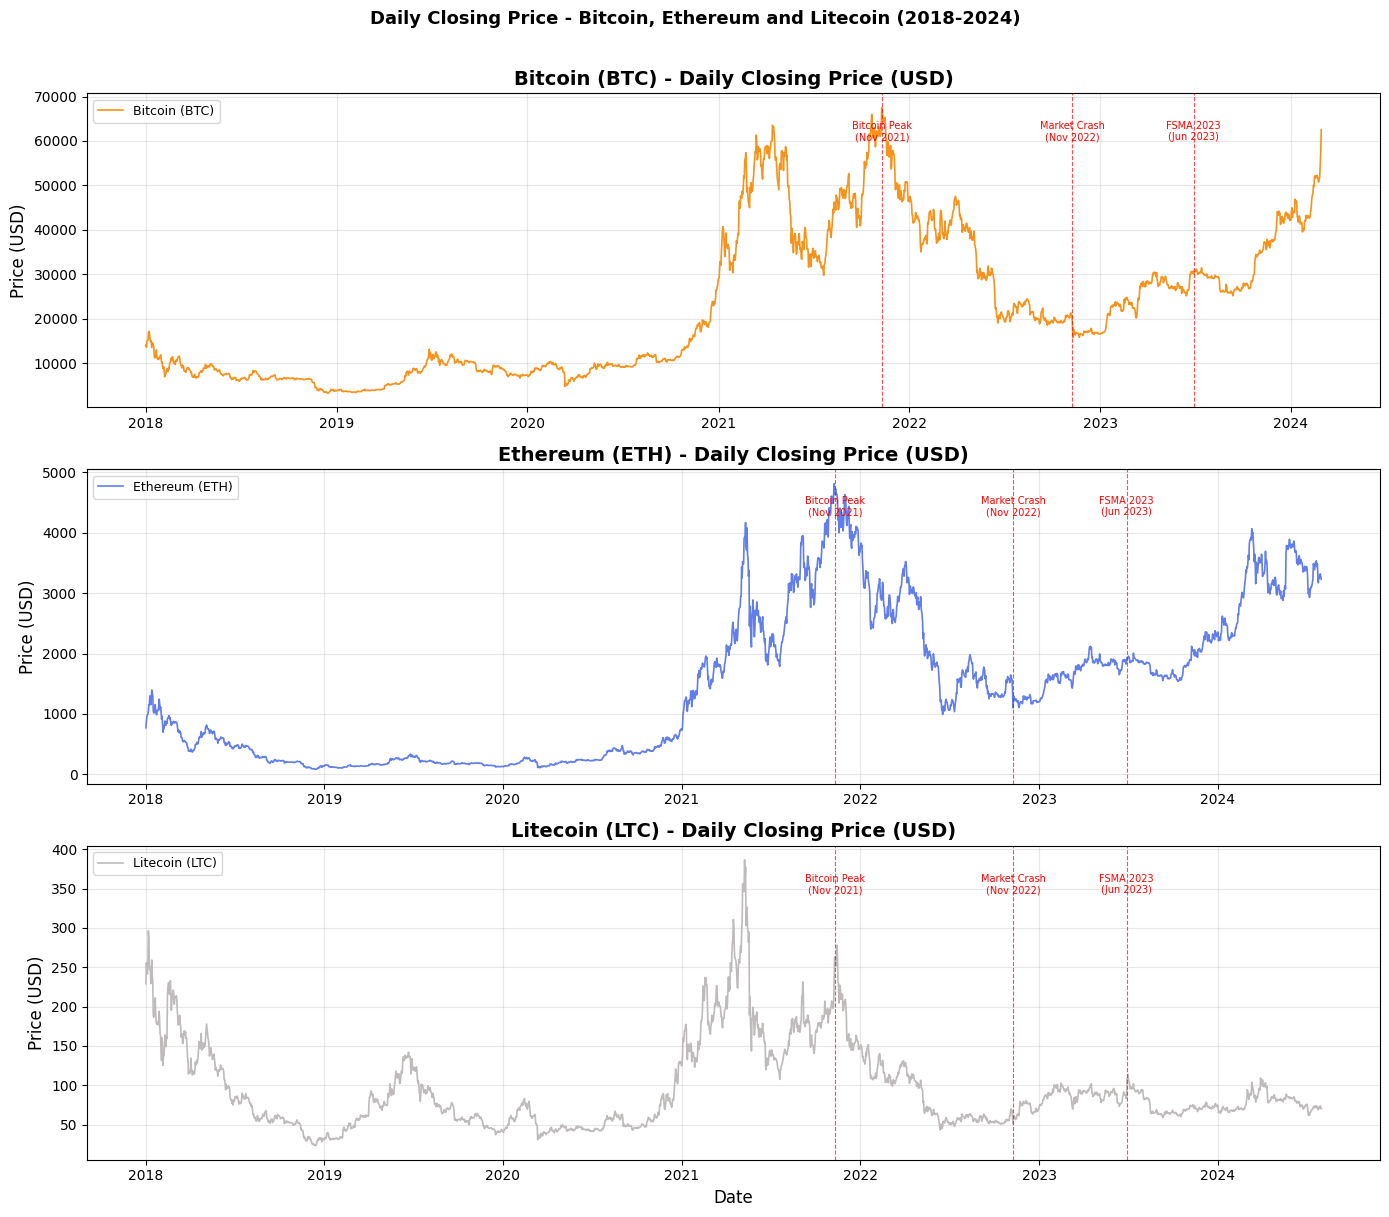

In [ ]:
# SECTION 6: FIGURE 1 - CLOSING PRICE TIME SERIES
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Key regulatory event dates
regulatory_dates = {
    'Bitcoin Peak\n(Nov 2021)': '2021-11-10',
    'Market Crash\n(Nov 2022)': '2022-11-09',
    'FSMA 2023\n(Jun 2023)': '2023-06-29'
}

colors = ['#F7931A', '#627EEA', '#BFBBBB']
assets = [('Bitcoin (BTC)', btc, colors[0]),
          ('Ethereum (ETH)', eth, colors[1]),
          ('Litecoin (LTC)', ltc, colors[2])]

for ax, (name, df, color) in zip(axes, assets):
    ax.plot(df['Date'], df['Close'], color=color, linewidth=1.2, label=name)
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.text(dt, ax.get_ylim()[1] * 0.85, label,
                    fontsize=7, color='red', ha='center')
    ax.set_title(f'{name} - Daily Closing Price (USD)', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Closing Price - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

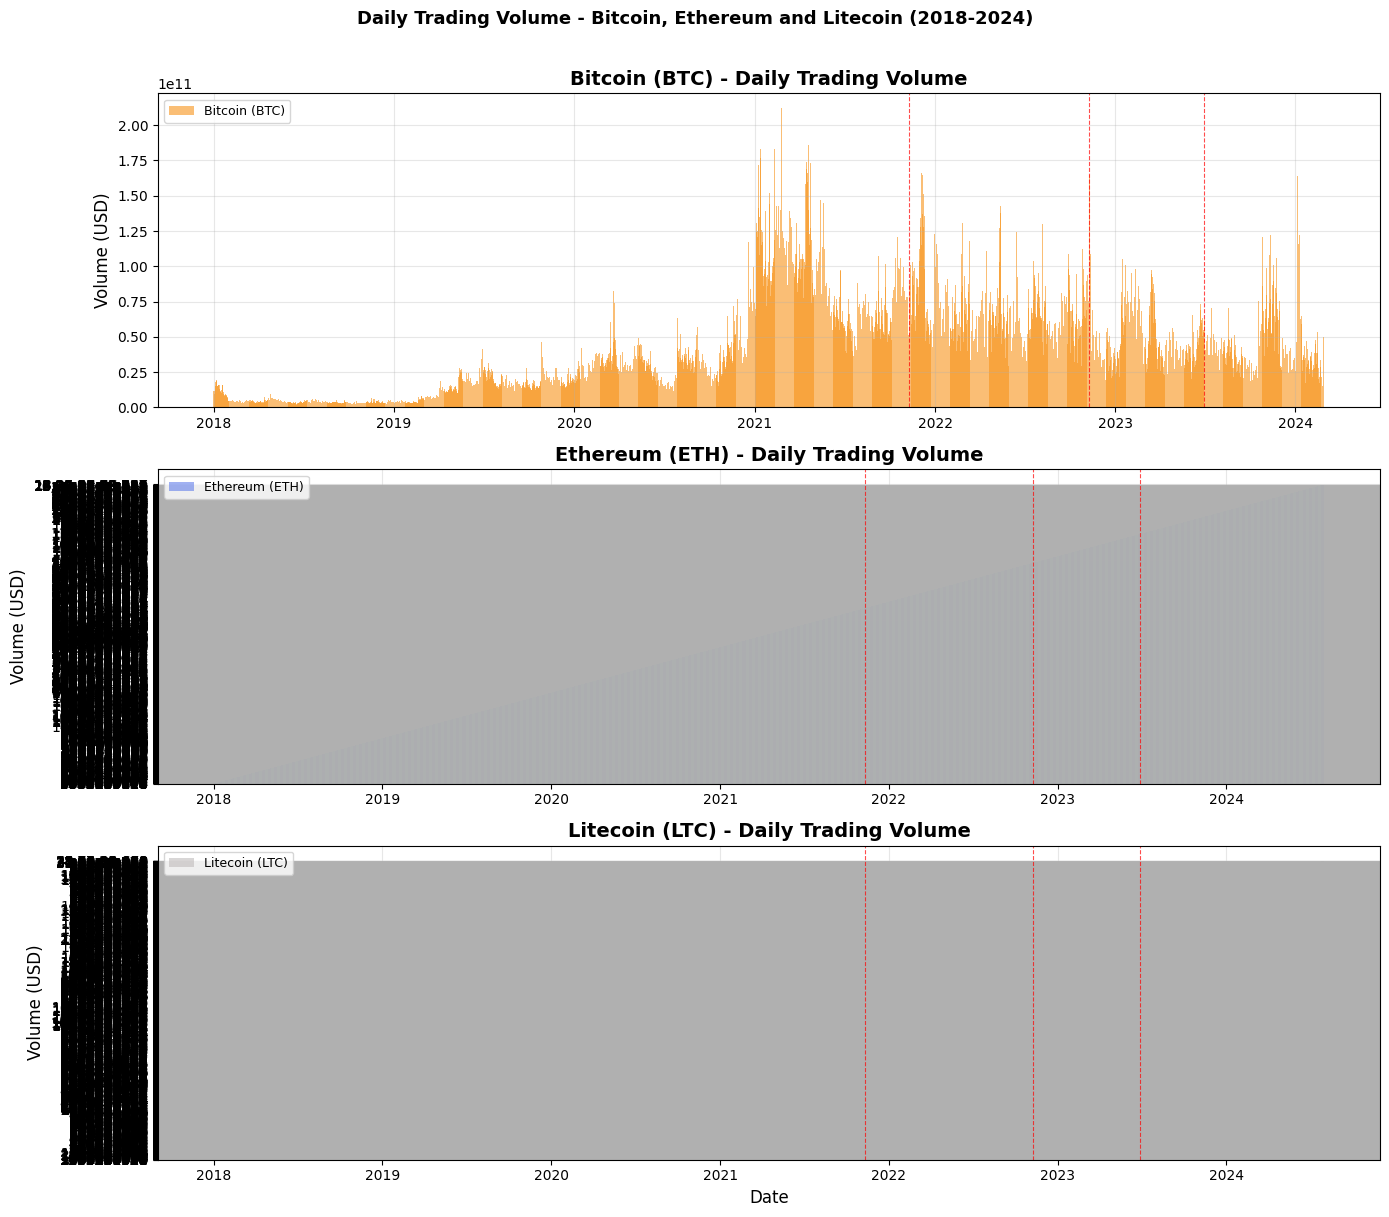

In [ ]:
# SECTION 7: FIGURE 2 - TRADING VOLUME TIME SERIES
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, (name, df, color) in zip(axes, assets):
    ax.bar(df['Date'], df['Volume'], color=color, alpha=0.6, width=1.5, label=name)
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(f'{name} - Daily Trading Volume', fontweight='bold')
    ax.set_ylabel('Volume (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Trading Volume - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


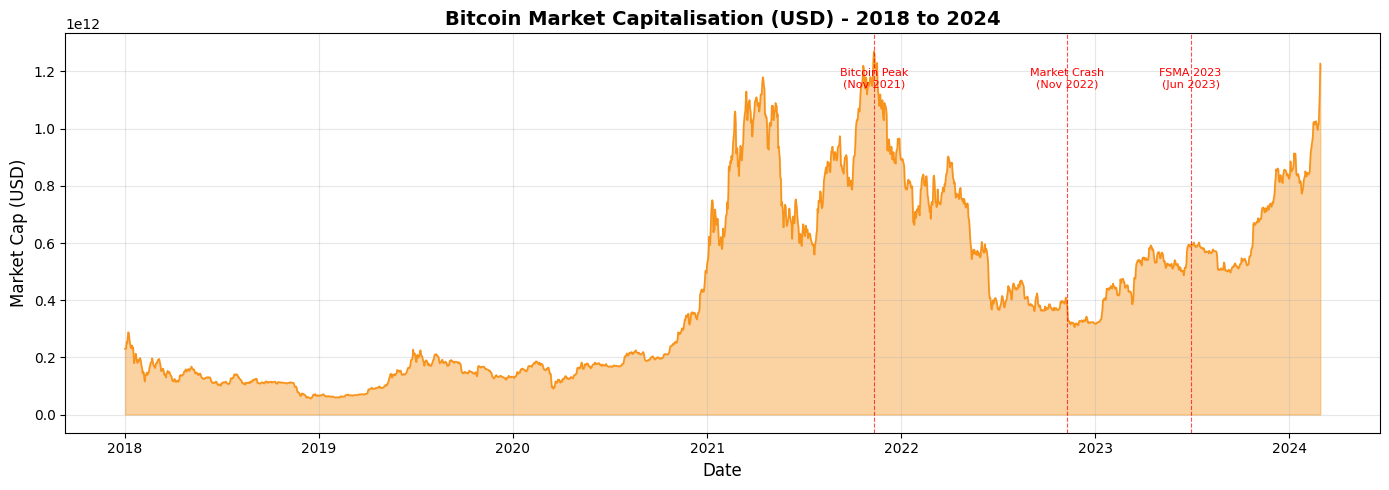

In [ ]:
# SECTION 8: FIGURE 3 - BITCOIN MARKET CAPITALISATION
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(btc['Date'], btc['Market Cap'], color='#F7931A', alpha=0.4)
ax.plot(btc['Date'], btc['Market Cap'], color='#F7931A', linewidth=1.2)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(dt, btc['Market Cap'].max() * 0.9, label,
            fontsize=8, color='red', ha='center')

ax.set_title('Bitcoin Market Capitalisation (USD) - 2018 to 2024',
             fontweight='bold')
ax.set_ylabel('Market Cap (USD)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


TABLE 2: PEARSON CORRELATION MATRIX - DAILY CLOSING PRICES
(Overlapping period: 2018-01-01 to 2024-02-28, n=2250 days)
          Bitcoin  Ethereum  Litecoin
Bitcoin    1.0000    0.9263    0.6195
Ethereum   0.9263    1.0000    0.5855
Litecoin   0.6195    0.5855    1.0000


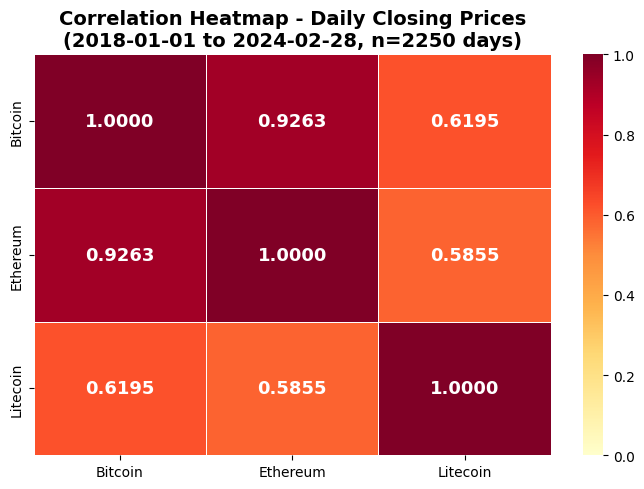

In [ ]:
# SECTION 9: CORRELATION ANALYSIS (TABLE 2)
# Merge on overlapping dates
merged = btc[['Date', 'Close']].merge(
    eth[['Date', 'Close']], on='Date', suffixes=('_btc', '_eth')
).merge(ltc[['Date', 'Close']], on='Date')
merged.rename(columns={'Close': 'Close_ltc'}, inplace=True)

corr_matrix = merged[['Close_btc', 'Close_eth', 'Close_ltc']].corr().round(4)
corr_matrix.index = ['Bitcoin', 'Ethereum', 'Litecoin']
corr_matrix.columns = ['Bitcoin', 'Ethereum', 'Litecoin']

print("\n" + "="*60)
print("TABLE 2: PEARSON CORRELATION MATRIX - DAILY CLOSING PRICES")
print(f"(Overlapping period: {merged['Date'].min().date()} to {merged['Date'].max().date()}, n={len(merged)} days)")
print("="*60)
print(corr_matrix.to_string())

# FIGURE 4 - CORRELATION HEATMAP
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Correlation Heatmap - Daily Closing Prices\n'
             f'(2018-01-01 to 2024-02-28, n={len(merged)} days)',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# SECTION 11: VOLATILITY ANALYSIS - DAILY RETURNS (TABLE 3)
# Calculate daily log returns
btc['Log_Return'] = np.log(btc['Close'] / btc['Close'].shift(1))
eth['Log_Return'] = np.log(eth['Close'] / eth['Close'].shift(1))
ltc['Log_Return'] = np.log(ltc['Close'] / ltc['Close'].shift(1))

# Annualised volatility (standard deviation of log returns * sqrt(365))
btc_vol = btc['Log_Return'].std() * np.sqrt(365)
eth_vol = eth['Log_Return'].std() * np.sqrt(365)
ltc_vol = ltc['Log_Return'].std() * np.sqrt(365)

print("\n" + "="*60)
print("TABLE 3: VOLATILITY ANALYSIS - DAILY LOG RETURNS")
print("="*60)

vol_stats = pd.DataFrame({
    'Bitcoin (BTC)': [
        round(btc['Log_Return'].mean() * 100, 4),
        round(btc['Log_Return'].std() * 100, 4),
        round(btc['Log_Return'].min() * 100, 4),
        round(btc['Log_Return'].max() * 100, 4),
        round(btc_vol * 100, 2)
    ],
    'Ethereum (ETH)': [
        round(eth['Log_Return'].mean() * 100, 4),
        round(eth['Log_Return'].std() * 100, 4),
        round(eth['Log_Return'].min() * 100, 4),
        round(eth['Log_Return'].max() * 100, 4),
        round(eth_vol * 100, 2)
    ],
    'Litecoin (LTC)': [
        round(ltc['Log_Return'].mean() * 100, 4),
        round(ltc['Log_Return'].std() * 100, 4),
        round(ltc['Log_Return'].min() * 100, 4),
        round(ltc['Log_Return'].max() * 100, 4),
        round(ltc_vol * 100, 2)
    ]
}, index=['Mean Daily Return (%)', 'Std Dev (%)', 'Min Return (%)',
          'Max Return (%)', 'Annualised Volatility (%)'])

print(vol_stats.to_string())


TABLE 3: VOLATILITY ANALYSIS - DAILY LOG RETURNS
                           Bitcoin (BTC)  Ethereum (ETH)  Litecoin (LTC)
Mean Daily Return (%)            -0.0664          0.0595         -0.0492
Std Dev (%)                       3.7022          4.6321          4.9378
Min Return (%)                  -17.2829        -55.0732        -44.9062
Max Return (%)                   51.8084         23.0695         29.0594
Annualised Volatility (%)        70.7300         88.5000         94.3400


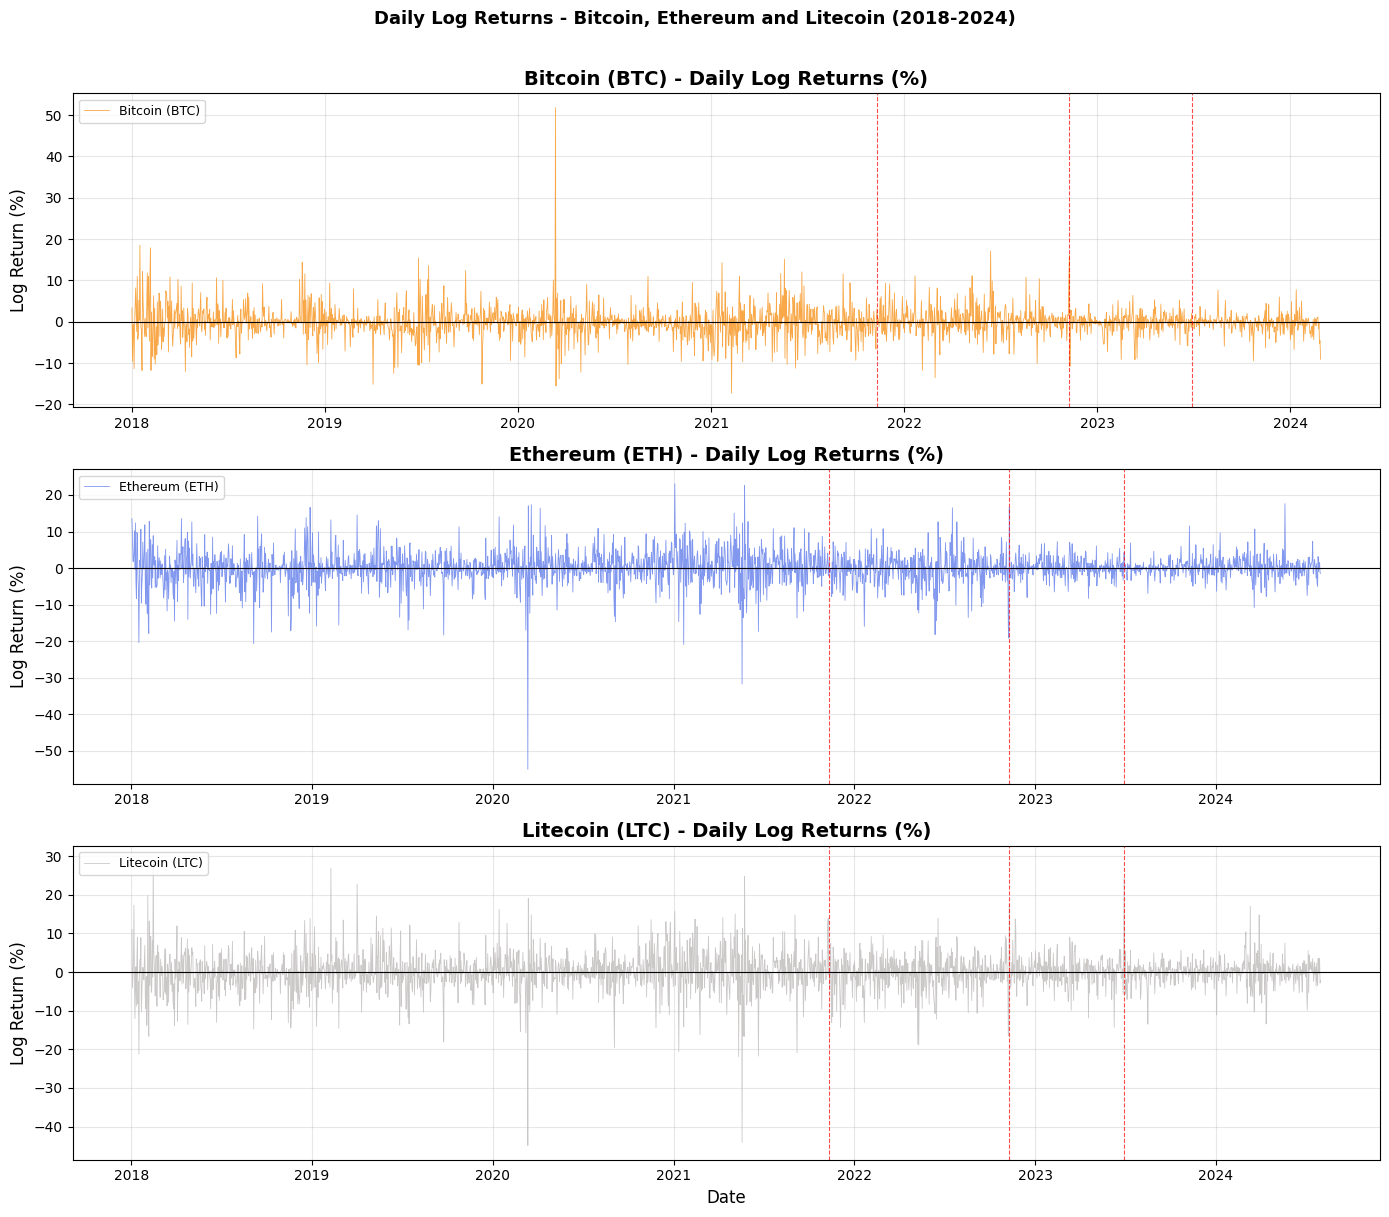

In [ ]:
# SECTION 12: FIGURE 5 - DAILY LOG RETURNS

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

return_colors = ['#F7931A', '#627EEA', '#BFBBBB']
return_assets = [('Bitcoin (BTC)', btc, return_colors[0]),
                 ('Ethereum (ETH)', eth, return_colors[1]),
                 ('Litecoin (LTC)', ltc, return_colors[2])]

for ax, (name, df, color) in zip(axes, return_assets):
    ax.plot(df['Date'], df['Log_Return'] * 100, color=color,
            linewidth=0.6, alpha=0.8, label=name)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--',
                       linewidth=0.8, alpha=0.7)
    ax.set_title(f'{name} - Daily Log Returns (%)', fontweight='bold')
    ax.set_ylabel('Log Return (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Log Returns - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# SECTION 13: CGT SIMULATION - OBJECTIVE 2
# Simulates annual CGT liability for a hypothetical UK investor
# holding a fixed quantity of each cryptocurrency
# Based on HMRC disposal rules: each year-end disposal is taxed
# at CGT rates with annual exempt amounts applied
print("\n" + "="*60)
print("TABLE 4: SIMULATED ANNUAL CGT LIABILITY - UK INVESTOR")
print("Assumptions: 1 BTC | 10 ETH | 100 LTC purchased Jan 2018")
print("Annual disposal at year-end closing price")
print("CGT rate: 20% (higher rate taxpayer)")
print("="*60)

# Quantities held
BTC_QTY = 1
ETH_QTY = 10
LTC_QTY = 100

# Cost basis (Jan 2018 opening prices)
BTC_COST = float(btc[btc['Date'] == '2018-01-01']['Open'].values[0])
ETH_COST = float(eth[eth['Date'] == '2018-01-01']['Open'].values[0])
LTC_COST = float(ltc[ltc['Date'] == '2018-01-01']['Open'].values[0])

# Annual exempt amounts per HMRC
exempt_amounts = {
    2018: 11700, 2019: 12000, 2020: 12300, 2021: 12300,
    2022: 12300, 2023: 6000, 2024: 3000
}

# CGT rate for higher rate taxpayer
CGT_RATE = 0.20

cgt_results = []

for year in range(2018, 2025):
    # Get year-end closing prices
    year_end = f'{year}-12-31'
    btc_year = btc[btc['Date'].dt.year == year]
    eth_year = eth[eth['Date'].dt.year == year]
    ltc_year = ltc[ltc['Date'].dt.year == year]

    if len(btc_year) == 0:
        continue

    btc_price = float(btc_year['Close'].iloc[-1])
    eth_price = float(eth_year['Close'].iloc[-1]) if len(eth_year) > 0 else 0
    ltc_price = float(ltc_year['Close'].iloc[-1]) if len(ltc_year) > 0 else 0

    # Calculate gains
    btc_gain = (btc_price - BTC_COST) * BTC_QTY
    eth_gain = (eth_price - ETH_COST) * ETH_QTY
    ltc_gain = (ltc_price - LTC_COST) * LTC_QTY
    total_gain = btc_gain + eth_gain + ltc_gain

    # Apply annual exempt amount
    exempt = exempt_amounts.get(year, 3000)
    taxable_gain = max(0, total_gain - exempt)
    cgt_liability = taxable_gain * CGT_RATE

    cgt_results.append({
        'Tax Year': f'{year}/{str(year+1)[-2:]}',
        'BTC Close (USD)': round(btc_price, 2),
        'ETH Close (USD)': round(eth_price, 2),
        'LTC Close (USD)': round(ltc_price, 2),
        'Total Gain (USD)': round(total_gain, 2),
        'CGT Exempt (USD)': exempt,
        'Taxable Gain (USD)': round(taxable_gain, 2),
        'CGT Liability (USD)': round(cgt_liability, 2)
    })

cgt_df = pd.DataFrame(cgt_results)
print(cgt_df.to_string(index=False))


TABLE 4: SIMULATED ANNUAL CGT LIABILITY - UK INVESTOR
Assumptions: 1 BTC | 10 ETH | 100 LTC purchased Jan 2018
Annual disposal at year-end closing price
CGT rate: 20% (higher rate taxpayer)
Tax Year  BTC Close (USD)  ETH Close (USD)  LTC Close (USD)  Total Gain (USD)  CGT Exempt (USD)  Taxable Gain (USD)  CGT Liability (USD)
 2018/19         14033.57           133.37            30.47         -24906.12             11700                0.00                 0.00
 2019/20          3746.12           129.61            41.34         -34143.95             12000                0.00                 0.00
 2020/21          7202.62           737.80           124.69         -16270.50             12300                0.00                 0.00
 2021/22         28977.96          3682.63           146.51          37135.58             12300            24835.58              4967.12
 2022/23         46304.95          1196.77            70.00          21952.09             12300             9652.09         

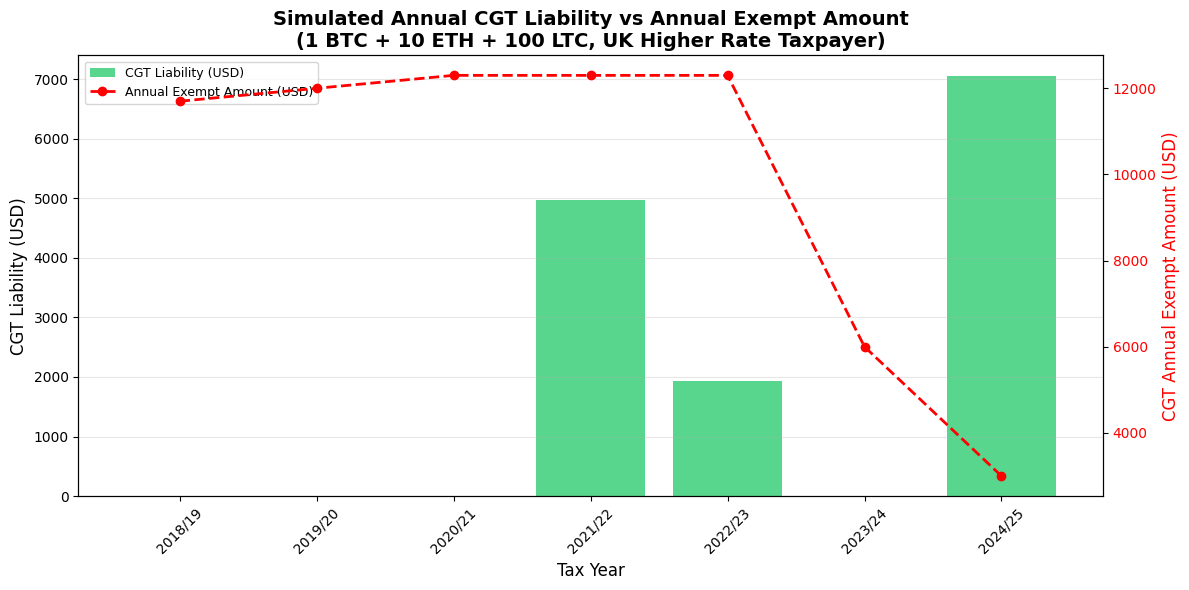

In [ ]:
# SECTION 14: FIGURE 6 - CGT LIABILITY OVER TIME
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(cgt_df))
bars = ax1.bar(x, cgt_df['CGT Liability (USD)'],
               color=['#2ecc71' if v >= 0 else '#e74c3c'
                      for v in cgt_df['CGT Liability (USD)']],
               alpha=0.8, label='CGT Liability (USD)')

ax1.set_xlabel('Tax Year')
ax1.set_ylabel('CGT Liability (USD)', color='black')
ax1.set_xticks(x)
ax1.set_xticklabels(cgt_df['Tax Year'], rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = ax1.twinx()
ax2.plot(x, cgt_df['CGT Exempt (USD)'], 'r--o',
         linewidth=2, markersize=6, label='Annual Exempt Amount (USD)')
ax2.set_ylabel('CGT Annual Exempt Amount (USD)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('Simulated Annual CGT Liability vs Annual Exempt Amount\n'
          '(1 BTC + 10 ETH + 100 LTC, UK Higher Rate Taxpayer)',
          fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# SECTION 15: REGULATORY EVENT IMPACT ANALYSIS - OBJECTIVE 3
# Examines price behaviour 30 days before and after key UK events
print("\n" + "="*60)
print("TABLE 5: PRICE IMPACT OF KEY UK REGULATORY EVENTS")
print("(Average closing price 30 days before vs 30 days after)")
print("="*60)

events = {
    'FSMA 2023 Royal Assent (29 Jun 2023)': '2023-06-29',
    'HMRC CGT Reduction (06 Apr 2023)': '2023-04-06',
    'Bitcoin Market Peak (10 Nov 2021)': '2021-11-10',
    'Crypto Market Crash (09 Nov 2022)': '2022-11-09'
}

event_results = []

for event_name, event_date in events.items():
    dt = pd.Timestamp(event_date)
    for asset_name, df in [('Bitcoin', btc), ('Ethereum', eth), ('Litecoin', ltc)]:
        before = df[(df['Date'] >= dt - pd.Timedelta(days=30)) &
                    (df['Date'] < dt)]['Close'].mean()
        after = df[(df['Date'] > dt) &
                   (df['Date'] <= dt + pd.Timedelta(days=30))]['Close'].mean()
        if pd.notna(before) and pd.notna(after):
            change_pct = ((after - before) / before) * 100
            event_results.append({
                'Event': event_name,
                'Asset': asset_name,
                'Avg Price Before (USD)': round(before, 2),
                'Avg Price After (USD)': round(after, 2),
                'Price Change (%)': round(change_pct, 2)
            })

event_df = pd.DataFrame(event_results)
print(event_df.to_string(index=False))


TABLE 5: PRICE IMPACT OF KEY UK REGULATORY EVENTS
(Average closing price 30 days before vs 30 days after)
                               Event    Asset  Avg Price Before (USD)  Avg Price After (USD)  Price Change (%)
FSMA 2023 Royal Assent (29 Jun 2023)  Bitcoin                27476.71               30157.47              9.76
FSMA 2023 Royal Assent (29 Jun 2023) Ethereum                 1818.36                1896.97              4.32
FSMA 2023 Royal Assent (29 Jun 2023) Litecoin                   85.07                  96.60             13.55
    HMRC CGT Reduction (06 Apr 2023)  Bitcoin                25850.29               28949.99             11.99
    HMRC CGT Reduction (06 Apr 2023) Ethereum                 1718.58                1927.18             12.14
    HMRC CGT Reduction (06 Apr 2023) Litecoin                   85.73                  91.07              6.24
   Bitcoin Market Peak (10 Nov 2021)  Bitcoin                61114.67               57211.93             -6.39
   Bi

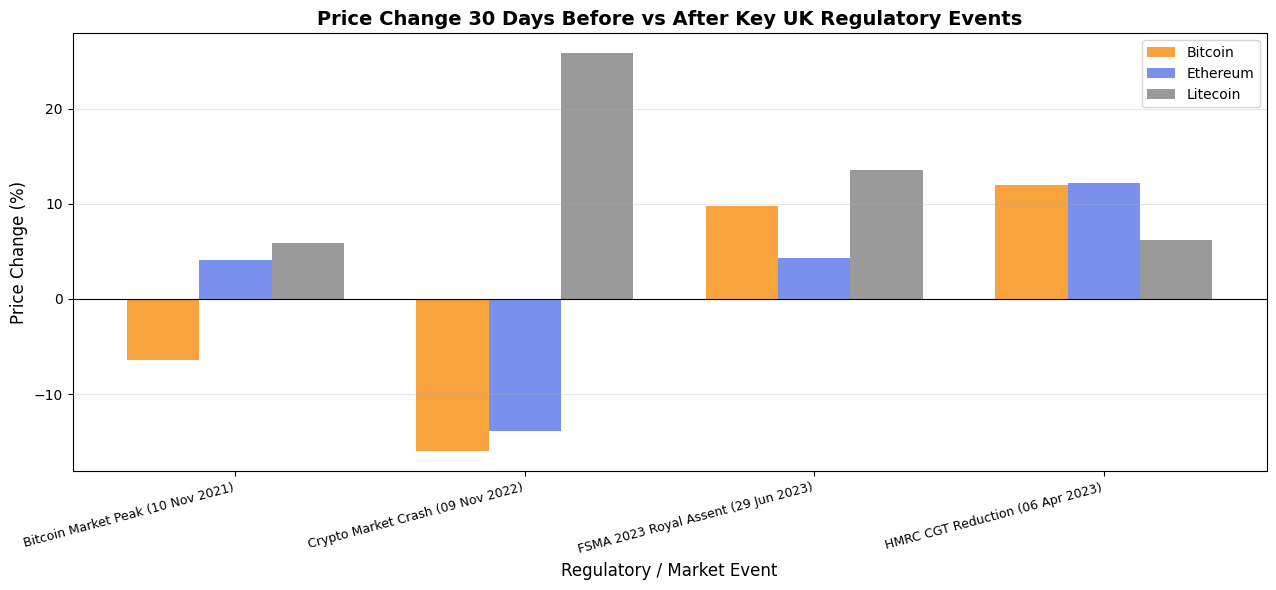

In [ ]:
# SECTION 16: FIGURE 7 - REGULATORY EVENT PRICE IMPACT
fig, ax = plt.subplots(figsize=(13, 6))

pivot = event_df.pivot(index='Event', columns='Asset', values='Price Change (%)')
x = np.arange(len(pivot.index))
width = 0.25

bars1 = ax.bar(x - width, pivot['Bitcoin'], width,
               label='Bitcoin', color='#F7931A', alpha=0.85)
bars2 = ax.bar(x, pivot['Ethereum'], width,
               label='Ethereum', color='#627EEA', alpha=0.85)
bars3 = ax.bar(x + width, pivot['Litecoin'], width,
               label='Litecoin', color='#888888', alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Regulatory / Market Event')
ax.set_ylabel('Price Change (%)')
ax.set_title('Price Change 30 Days Before vs After Key UK Regulatory Events',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# SECTION 17: RISK AND OPPORTUNITY ANALYSIS - OBJECTIVE 4
# Rolling 30-day volatility and Sharpe Ratio
# Rolling 30-day volatility
btc['Rolling_Vol_30'] = btc['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100
eth['Rolling_Vol_30'] = eth['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100
ltc['Rolling_Vol_30'] = ltc['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100

# Sharpe Ratio (risk-free rate = 2% annual, approximate UK base rate average)
RISK_FREE_RATE = 0.02 / 365

btc_sharpe = (btc['Log_Return'].mean() - RISK_FREE_RATE) / btc['Log_Return'].std()
eth_sharpe = (eth['Log_Return'].mean() - RISK_FREE_RATE) / eth['Log_Return'].std()
ltc_sharpe = (ltc['Log_Return'].mean() - RISK_FREE_RATE) / ltc['Log_Return'].std()

print("\n" + "="*60)
print("TABLE 6: RISK AND RETURN SUMMARY - OBJECTIVE 4")
print("="*60)

risk_df = pd.DataFrame({
    'Metric': [
        'Annualised Volatility (%)',
        'Annualised Return (%)',
        'Sharpe Ratio (daily)',
        'Max Drawdown (%)',
        'Value at Risk 95% (daily %)'
    ],
    'Bitcoin': [
        round(btc_vol * 100, 2),
        round(btc['Log_Return'].mean() * 365 * 100, 2),
        round(btc_sharpe, 4),
        round(((btc['Close'] / btc['Close'].cummax()) - 1).min() * 100, 2),
        round(btc['Log_Return'].quantile(0.05) * 100, 4)
    ],
    'Ethereum': [
        round(eth_vol * 100, 2),
        round(eth['Log_Return'].mean() * 365 * 100, 2),
        round(eth_sharpe, 4),
        round(((eth['Close'] / eth['Close'].cummax()) - 1).min() * 100, 2),
        round(eth['Log_Return'].quantile(0.05) * 100, 4)
    ],
    'Litecoin': [
        round(ltc_vol * 100, 2),
        round(ltc['Log_Return'].mean() * 365 * 100, 2),
        round(ltc_sharpe, 4),
        round(((ltc['Close'] / ltc['Close'].cummax()) - 1).min() * 100, 2),
        round(ltc['Log_Return'].quantile(0.05) * 100, 4)
    ]
})
print(risk_df.to_string(index=False))



TABLE 6: RISK AND RETURN SUMMARY - OBJECTIVE 4
                     Metric  Bitcoin  Ethereum  Litecoin
  Annualised Volatility (%)  70.7300   88.5000   94.3400
      Annualised Return (%) -24.2400   21.7300  -17.9600
       Sharpe Ratio (daily)  -0.0194    0.0117   -0.0111
           Max Drawdown (%) -95.2000  -93.9600  -92.0900
Value at Risk 95% (daily %)  -5.6251   -7.2049   -7.9345


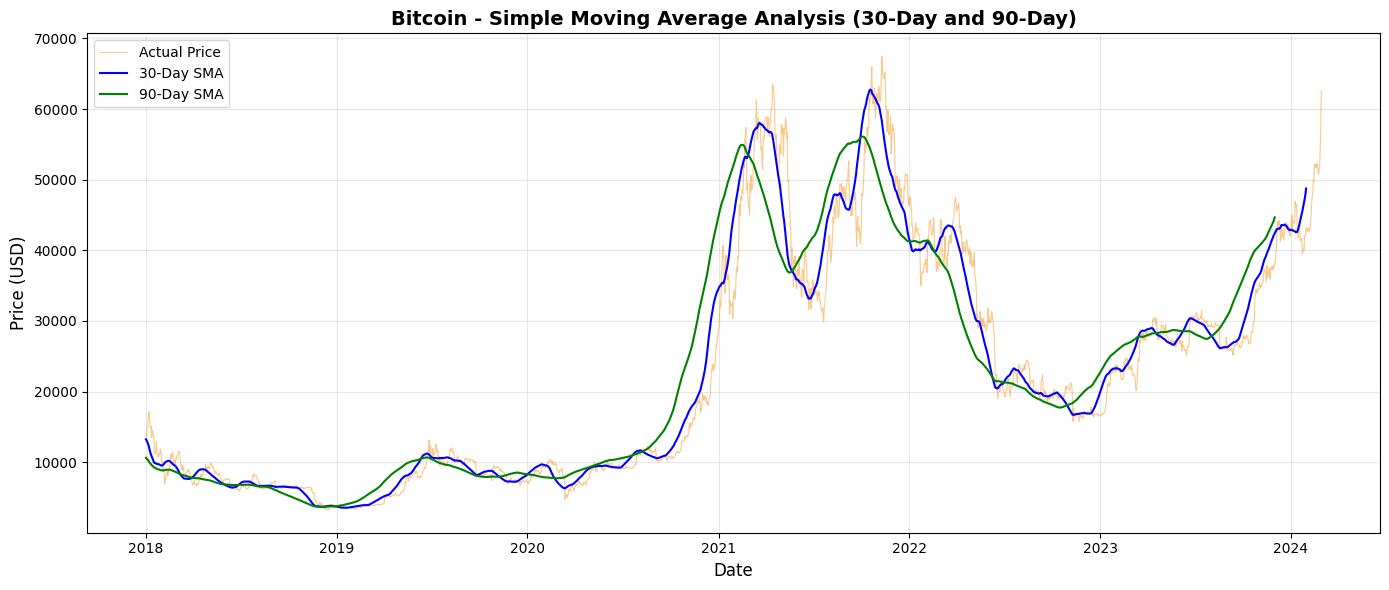


TABLE 7: SMA CROSSOVER SIGNALS - BITCOIN
(30-Day SMA crossing 90-Day SMA)
      Date        Close       SMA_30       SMA_90        Signal
2020-01-01  7202.624251  8266.149755  8292.555075 Bearish Cross
2019-11-07  9329.520807  8014.845135  7958.022847 Bullish Cross
2019-06-11  8000.570019 10462.610627 10486.905548 Bearish Cross
2018-12-26  3789.436638  3772.177427  3765.828904 Bullish Cross
2018-12-08  3424.127676  3691.970222  3692.447605 Bearish Cross
2018-12-02  4208.469723  3705.408594  3697.769413 Bullish Cross
2018-06-27  6103.030720  6761.218111  6785.850583 Bearish Cross
2018-05-30  7474.562016  6900.677391  6872.512417 Bullish Cross
2018-03-30  7178.058623  7785.340141  7799.744112 Bearish Cross
2018-03-07 10697.572290  8384.951663  8317.796010 Bullish Cross


In [ ]:
# SECTION: MOVING AVERAGE FORECASTING - BITCOIN (OBJECTIVE 1)
# 30-day and 90-day Simple Moving Averages
# Informed by Phung Duy et al. (2024) time series methodology
btc['SMA_30'] = btc['Close'].rolling(window=30).mean()
btc['SMA_90'] = btc['Close'].rolling(window=90).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(btc['Date'], btc['Close'],
        color='#F7931A', linewidth=0.8, alpha=0.5, label='Actual Price')
ax.plot(btc['Date'], btc['SMA_30'],
        color='blue', linewidth=1.5, label='30-Day SMA')
ax.plot(btc['Date'], btc['SMA_90'],
        color='green', linewidth=1.5, label='90-Day SMA')
ax.set_title('Bitcoin - Simple Moving Average Analysis (30-Day and 90-Day)',
             fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# SMA Crossover Signal Table
btc['Signal'] = 0
btc.loc[btc['SMA_30'] > btc['SMA_90'], 'Signal'] = 1
btc.loc[btc['SMA_30'] < btc['SMA_90'], 'Signal'] = -1

crossovers = btc[btc['Signal'].diff() != 0][['Date', 'Close', 'SMA_30', 'SMA_90', 'Signal']].dropna()
crossovers['Signal'] = crossovers['Signal'].map({1: 'Bullish Cross', -1: 'Bearish Cross'})

print("\nTABLE 7: SMA CROSSOVER SIGNALS - BITCOIN")
print("(30-Day SMA crossing 90-Day SMA)")
print(crossovers.tail(10).to_string(index=False))

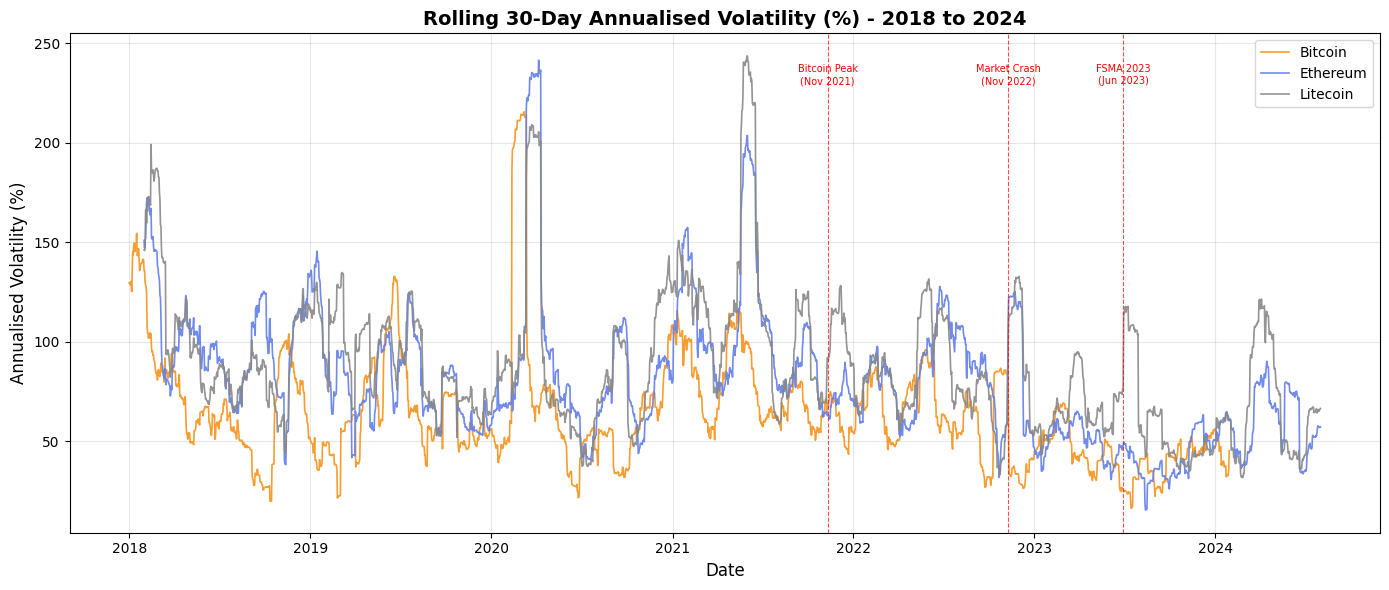

In [ ]:
# SECTION 18: FIGURE 8 - ROLLING 30-DAY VOLATILITY
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(btc['Date'], btc['Rolling_Vol_30'],
        color='#F7931A', linewidth=1.2, label='Bitcoin', alpha=0.9)
ax.plot(eth['Date'], eth['Rolling_Vol_30'],
        color='#627EEA', linewidth=1.2, label='Ethereum', alpha=0.9)
ax.plot(ltc['Date'], ltc['Rolling_Vol_30'],
        color='#888888', linewidth=1.2, label='Litecoin', alpha=0.9)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(dt, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 200,
            label, fontsize=7, color='red', ha='center')

ax.set_title('Rolling 30-Day Annualised Volatility (%) - 2018 to 2024',
             fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

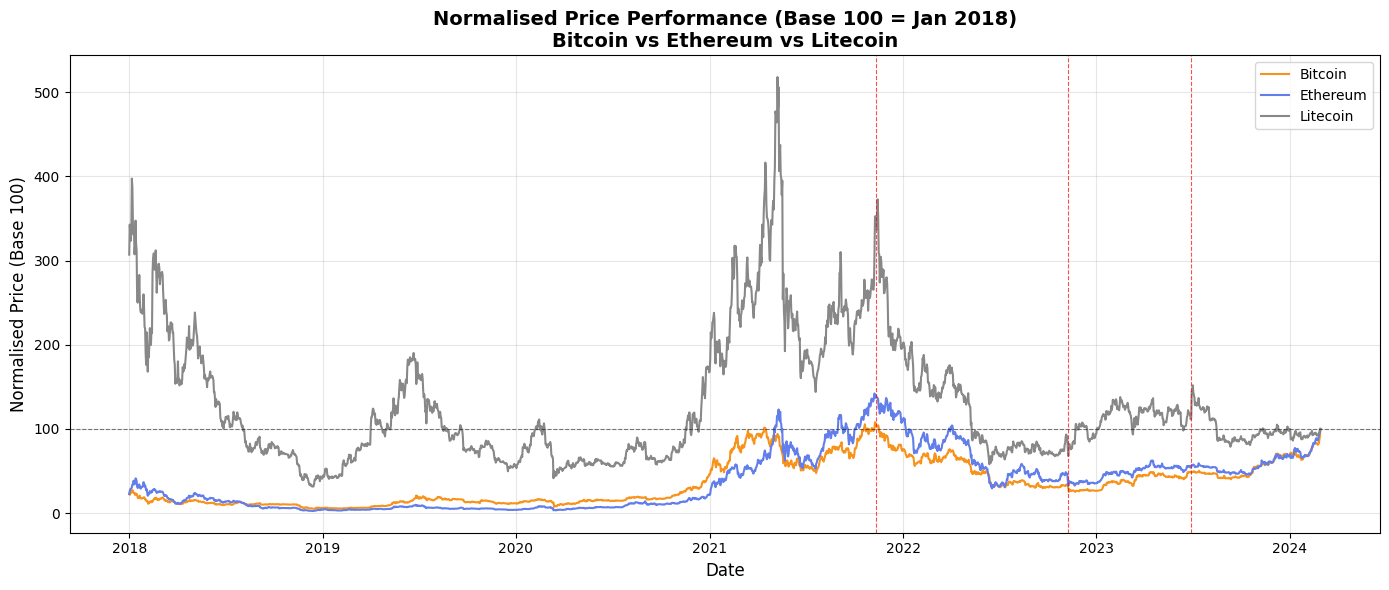

In [ ]:
# SECTION 19: FIGURE 9 - NORMALISED PRICE COMPARISON
# (Base 100 from Jan 2018 for direct comparison)
# Merge on common dates
common = btc[['Date', 'Close']].merge(
    eth[['Date', 'Close']], on='Date', suffixes=('_btc', '_eth')
).merge(ltc[['Date', 'Close']], on='Date')
common.rename(columns={'Close': 'Close_ltc'}, inplace=True)

# Normalise to base 100
common['BTC_norm'] = (common['Close_btc'] / common['Close_btc'].iloc[0]) * 100
common['ETH_norm'] = (common['Close_eth'] / common['Close_eth'].iloc[0]) * 100
common['LTC_norm'] = (common['Close_ltc'] / common['Close_ltc'].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(common['Date'], common['BTC_norm'],
        color='#F7931A', linewidth=1.5, label='Bitcoin')
ax.plot(common['Date'], common['ETH_norm'],
        color='#627EEA', linewidth=1.5, label='Ethereum')
ax.plot(common['Date'], common['LTC_norm'],
        color='#888888', linewidth=1.5, label='Litecoin')

ax.axhline(y=100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('Normalised Price Performance (Base 100 = Jan 2018)\n'
             'Bitcoin vs Ethereum vs Litecoin', fontweight='bold')
ax.set_ylabel('Normalised Price (Base 100)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# SECTION 20: SUMMARY OF ALL OUTPUTS
print("\n" + "="*60)
print("IMPLEMENTATION COMPLETE - OUTPUTS GENERATED")
print("="*60)



IMPLEMENTATION COMPLETE - OUTPUTS GENERATED


Machine learning Models

In [ ]:
pip install pandas numpy statsmodels arch matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 20.4 MB/s eta 0:00:00


ADF p-value: 0.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA(1,0,2) AIC=12266.25
                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 2249
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -6128.124
Date:                Wed, 15 Jul 2026   AIC                          12266.248
Time:                        10:01:17   BIC                          12294.839
Sample:                    01-02-2018   HQIC                         12276.684
                         - 02-28-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0677      0.088      0.770      0.441      -0.105       0.240
ar.L1          0.6457      0.183      3.536      0.000       0.288       1.004
ma.L1         -0.6983

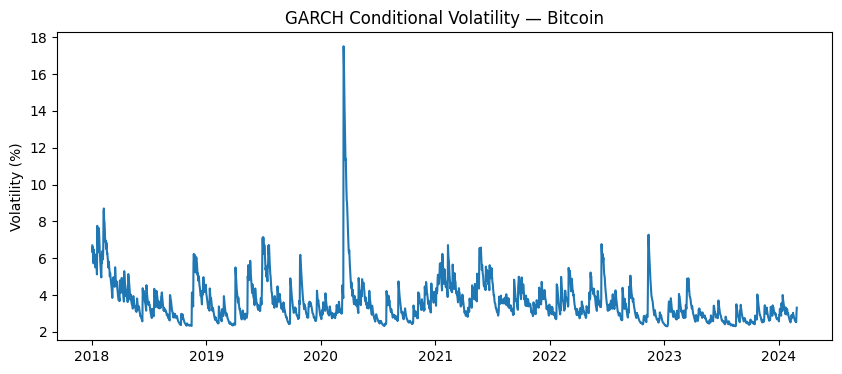

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

# ---- Load & clean (same idea as your project) ----
btc = pd.read_csv("/content/BITCOIN24.csv")
btc["Date"] = pd.to_datetime(btc["Date"], dayfirst=True)
btc = btc.sort_values("Date").dropna(subset=["Close"])

# Log returns (%) — usual input for GARCH
btc["log_ret"] = np.log(btc["Close"] / btc["Close"].shift(1)) * 100

# Set Date as index for the log returns Series to support forecasting
rets = btc.set_index("Date")["log_ret"].dropna()

# ---- Check stationarity (ADF test) ----
adf_stat, adf_p, *_ = adfuller(rets)
print("ADF p-value:", adf_p)  # p < 0.05 → returns are stationary

# ---- Step A: ARIMA on returns (mean model) ----
# Try small orders; pick lowest AIC
best = None
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = ARIMA(rets, order=(p, 0, q)).fit()
            if best is None or m.aic < best[0]:
                best = (m.aic, p, q, m)
        except Exception:
            pass

aic, p, q, arima_fit = best
print(f"Best ARIMA({p},0,{q}) AIC={aic:.2f}")
print(arima_fit.summary())

# ARIMA residuals → feed into GARCH
resid = arima_fit.resid.dropna()

# ---- Step B: GARCH(1,1) on residuals (volatility model) ----
garch = arch_model(resid, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
garch_fit = garch.fit(disp="off")
print(garch_fit.summary())

# ---- Forecast next 5 days ----
arima_fc = arima_fit.forecast(5)
garch_fc = garch_fit.forecast(horizon=5)
print("Mean forecast (ARIMA):", arima_fc.values)
print("Volatility forecast (GARCH):", np.sqrt(garch_fc.variance.values[-1]))

# ---- Plot conditional volatility ----
cond_vol = garch_fit.conditional_volatility
plt.figure(figsize=(10, 4))
plt.plot(cond_vol.index, cond_vol.values)
plt.title("GARCH Conditional Volatility — Bitcoin")
plt.ylabel("Volatility (%)")
plt.show()

ADF p-value: 2.1325474826161954e-27


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA(1,0,2) AIC=14111.22
                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 2390
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -7050.612
Date:                Wed, 15 Jul 2026   AIC                          14111.224
Time:                        10:32:52   BIC                          14140.119
Sample:                    01-02-2018   HQIC                         14121.739
                         - 07-18-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0633      0.109      0.580      0.562      -0.150       0.277
ar.L1          0.6438      0.143      4.492      0.000       0.363       0.925
ma.L1         -0.6977

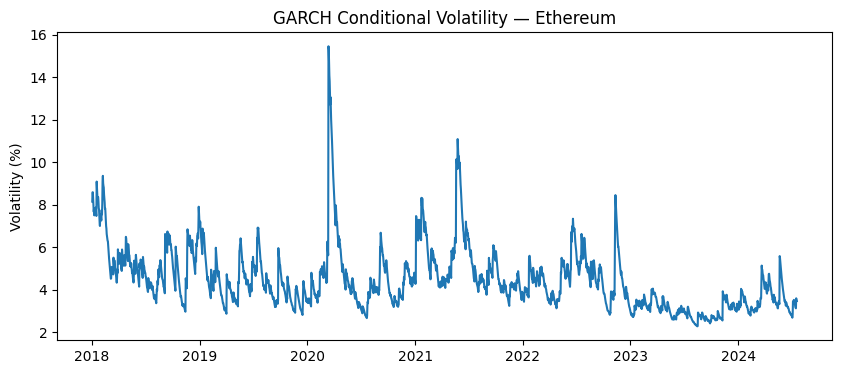

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

# ---- Load & clean (same idea as your project) ----
eth = pd.read_csv("/content/ETHEREUM.csv")
eth["Date"] = pd.to_datetime(eth["Date"], dayfirst=True, errors="coerce")
eth["Close"] = pd.to_numeric(eth["Close"], errors="coerce")
eth = eth.sort_values("Date").dropna(subset=["Close"]).reset_index(drop=True)

# Log returns (%) — usual input for GARCH
eth["log_ret"] = np.log(eth["Close"] / eth["Close"].shift(1)) * 100

# Set Date as index for the log returns Series to support forecasting
rets = eth.set_index("Date")["log_ret"].dropna()

# ---- Check stationarity (ADF test) ----
adf_stat, adf_p, *_ = adfuller(rets)
print("ADF p-value:", adf_p)  # p < 0.05 → returns are stationary

# ---- Step A: ARIMA on returns (mean model) ----
# Try small orders; pick lowest AIC
best = None
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = ARIMA(rets, order=(p, 0, q)).fit()
            if best is None or m.aic < best[0]:
                best = (m.aic, p, q, m)
        except Exception:
            pass

aic, p, q, arima_fit = best
print(f"Best ARIMA({p},0,{q}) AIC={aic:.2f}")
print(arima_fit.summary())

# ARIMA residuals → feed into GARCH
resid = arima_fit.resid.dropna()

# ---- Step B: GARCH(1,1) on residuals (volatility model) ----
garch = arch_model(resid, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
garch_fit = garch.fit(disp="off")
print(garch_fit.summary())

# ---- Forecast next 5 days ----
arima_fc = arima_fit.forecast(5)
garch_fc = garch_fit.forecast(horizon=5)
print("Mean forecast (ARIMA):", arima_fc.values)
print("Volatility forecast (GARCH):", np.sqrt(garch_fc.variance.values[-1]))

# ---- Plot conditional volatility ----
cond_vol = garch_fit.conditional_volatility
plt.figure(figsize=(10, 4))
plt.plot(cond_vol.index, cond_vol.values)
plt.title("GARCH Conditional Volatility — Ethereum")
plt.ylabel("Volatility (%)")
plt.show()

ADF p-value: 2.6854471865828553e-30


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA(2,0,2) AIC=14489.52
                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 2403
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -7238.759
Date:                Wed, 15 Jul 2026   AIC                          14489.519
Time:                        10:38:23   BIC                          14524.226
Sample:                    01-02-2018   HQIC                         14502.144
                         - 07-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0494      0.101     -0.488      0.626      -0.248       0.149
ar.L1         -1.8250      0.058    -31.236      0.000      -1.939      -1.710
ar.L2         -0.9045

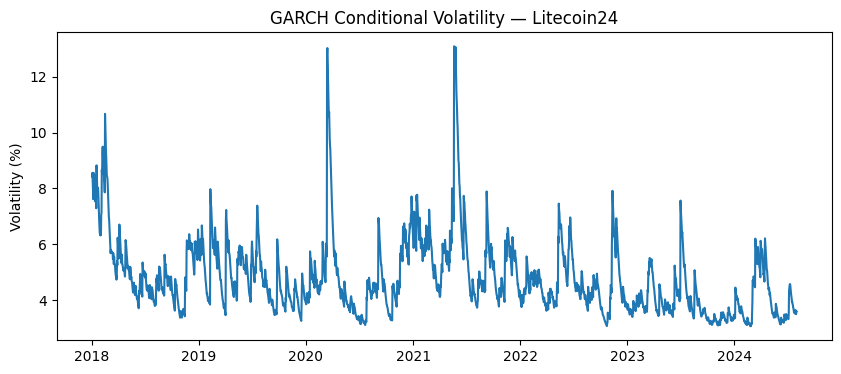

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

# ---- Load & clean (same idea as your project) ----
ltc = pd.read_csv("/content/LITECOIN24.csv")
ltc["Date"] = pd.to_datetime(ltc["Date"], dayfirst=True, errors="coerce")
ltc["Close"] = pd.to_numeric(ltc["Close"], errors="coerce")
ltc = ltc.sort_values("Date").dropna(subset=["Close"]).reset_index(drop=True)

# Log returns (%) — usual input for GARCH
ltc["log_ret"] = np.log(ltc["Close"] / ltc["Close"].shift(1)) * 100

# Set Date as index for the log returns Series to support forecasting
rets = ltc.set_index("Date")["log_ret"].dropna()

# ---- Check stationarity (ADF test) ----
adf_stat, adf_p, *_ = adfuller(rets)
print("ADF p-value:", adf_p)  # p < 0.05 → returns are stationary

# ---- Step A: ARIMA on returns (mean model) ----
# Try small orders; pick lowest AIC
best = None
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = ARIMA(rets, order=(p, 0, q)).fit()
            if best is None or m.aic < best[0]:
                best = (m.aic, p, q, m)
        except Exception:
            pass

aic, p, q, arima_fit = best
print(f"Best ARIMA({p},0,{q}) AIC={aic:.2f}")
print(arima_fit.summary())

# ARIMA residuals → feed into GARCH
resid = arima_fit.resid.dropna()

# ---- Step B: GARCH(1,1) on residuals (volatility model) ----
garch = arch_model(resid, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
garch_fit = garch.fit(disp="off")
print(garch_fit.summary())

# ---- Forecast next 5 days ----
arima_fc = arima_fit.forecast(5)
garch_fc = garch_fit.forecast(horizon=5)
print("Mean forecast (ARIMA):", arima_fc.values)
print("Volatility forecast (GARCH):", np.sqrt(garch_fc.variance.values[-1]))

# ---- Plot conditional volatility ----
cond_vol = garch_fit.conditional_volatility
plt.figure(figsize=(10, 4))
plt.plot(cond_vol.index, cond_vol.values)
plt.title("GARCH Conditional Volatility — Litecoin24")
plt.ylabel("Volatility (%)")
plt.show()

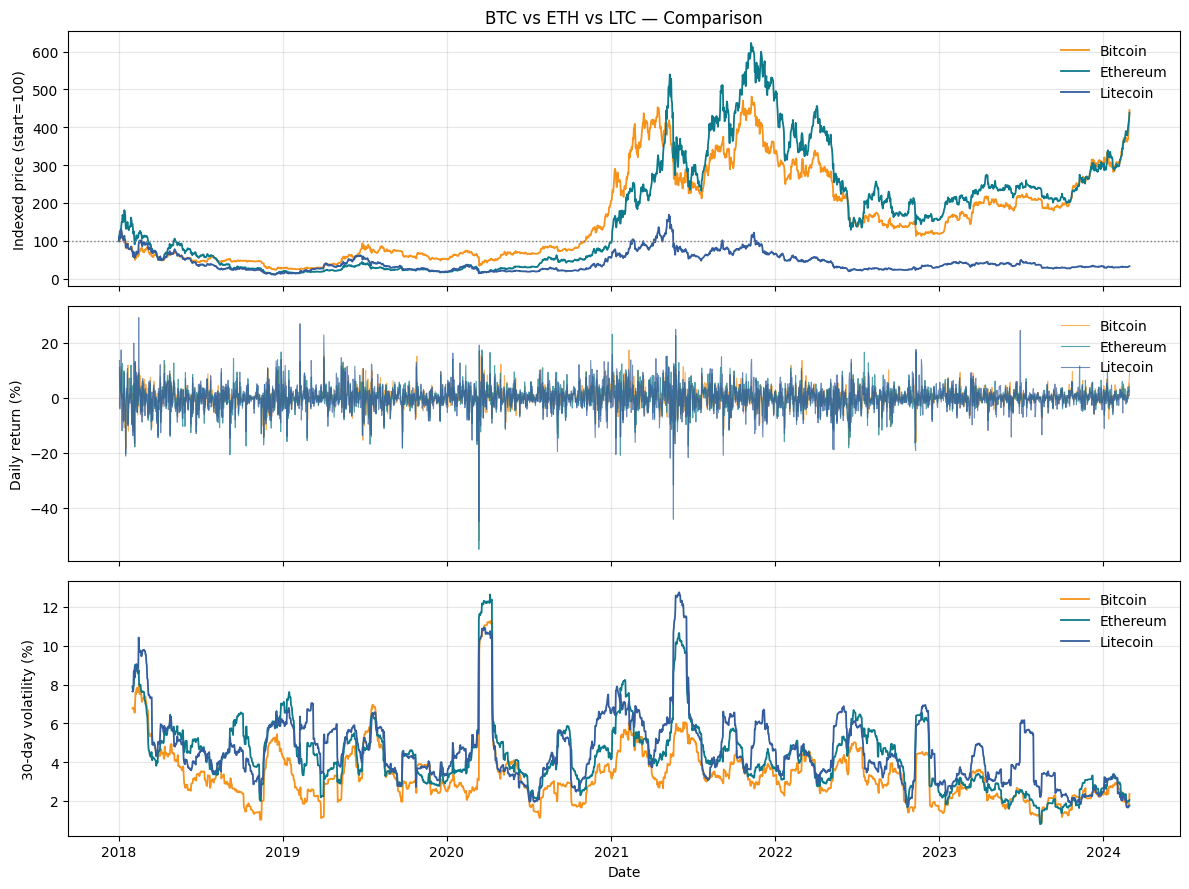

Overlapping days: 2250
Mean |return| (%)
 BTC: 2.411
 ETH: 3.176
 LTC: 3.403
Mean 30-day vol (%)
 BTC: 3.352
 ETH: 4.308
 LTC: 4.638


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load & clean ----------
def load_coin(path, name):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"]).sort_values("Date")
    df = df.set_index("Date")
    df["ret"] = np.log(df["Close"] / df["Close"].shift(1)) * 100
    df["vol30"] = df["ret"].rolling(30).std()
    df["norm"] = df["Close"] / df["Close"].iloc[0] * 100  # start = 100
    df["Asset"] = name
    return df

btc = load_coin("BITCOIN24.csv", "Bitcoin")
eth = load_coin("ETHEREUM.csv", "Ethereum")
ltc = load_coin("LITECOIN24.csv", "Litecoin")

# Common overlapping dates only
common = btc.index.intersection(eth.index).intersection(ltc.index)
btc, eth, ltc = btc.loc[common], eth.loc[common], ltc.loc[common]

# ---------- One figure, 3 comparison panels ----------
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# 1) Normalized price (fair comparison across different USD levels)
axes[0].plot(btc.index, btc["norm"], label="Bitcoin", color="#F7931A", lw=1.3)
axes[0].plot(eth.index, eth["norm"], label="Ethereum", color="#0D7A8C", lw=1.3)
axes[0].plot(ltc.index, ltc["norm"], label="Litecoin", color="#345D9D", lw=1.3)
axes[0].axhline(100, color="grey", ls=":", lw=1)
axes[0].set_ylabel("Indexed price (start=100)")
axes[0].set_title("BTC vs ETH vs LTC — Comparison")
axes[0].legend(frameon=False)
axes[0].grid(True, alpha=0.3)

# 2) Daily log returns (%)
axes[1].plot(btc.index, btc["ret"], label="Bitcoin", color="#F7931A", alpha=0.7, lw=0.8)
axes[1].plot(eth.index, eth["ret"], label="Ethereum", color="#0D7A8C", alpha=0.7, lw=0.8)
axes[1].plot(ltc.index, ltc["ret"], label="Litecoin", color="#345D9D", alpha=0.7, lw=0.8)
axes[1].set_ylabel("Daily return (%)")
axes[1].legend(frameon=False, loc="upper right")
axes[1].grid(True, alpha=0.3)

# 3) 30-day rolling volatility
axes[2].plot(btc.index, btc["vol30"], label="Bitcoin", color="#F7931A", lw=1.3)
axes[2].plot(eth.index, eth["vol30"], label="Ethereum", color="#0D7A8C", lw=1.3)
axes[2].plot(ltc.index, ltc["vol30"], label="Litecoin", color="#345D9D", lw=1.3)
axes[2].set_ylabel("30-day volatility (%)")
axes[2].set_xlabel("Date")
axes[2].legend(frameon=False)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional quick stats print
print("Overlapping days:", len(common))
print("Mean |return| (%)")
print(" BTC:", round(btc["ret"].abs().mean(), 3))
print(" ETH:", round(eth["ret"].abs().mean(), 3))
print(" LTC:", round(ltc["ret"].abs().mean(), 3))
print("Mean 30-day vol (%)")
print(" BTC:", round(btc["vol30"].mean(), 3))
print(" ETH:", round(eth["vol30"].mean(), 3))
print(" LTC:", round(ltc["vol30"].mean(), 3))


Bitcoin | Price Direction (UP/DOWN)
Train=1728 | Test=433
Test class balance:
price_class
1    0.517
0    0.483
Name: proportion, dtype: float64

--- Logistic Regression ---
Accuracy : 0.5173
Precision: 0.5177
Recall   : 0.9777
F1-score : 0.6770
              precision    recall  f1-score   support

           0      0.500     0.024     0.046       209
           1      0.518     0.978     0.677       224

    accuracy                          0.517       433
   macro avg      0.509     0.501     0.361       433
weighted avg      0.509     0.517     0.372       433

Confusion matrix:
[[  5 204]
 [  5 219]]

--- Random Forest ---
Accuracy : 0.5219
Precision: 0.5282
Recall   : 0.7098
F1-score : 0.6057
              precision    recall  f1-score   support

           0      0.508     0.321     0.393       209
           1      0.528     0.710     0.606       224

    accuracy                          0.522       433
   macro avg      0.518     0.515     0.499       433
weighted avg      

/tmp/ipykernel_474/2684950367.py:55: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["vol_change"] = df["Volume"].pct_change()



--- Random Forest ---
Accuracy : 0.5098
Precision: 0.5342
Recall   : 0.4855
F1-score : 0.5087
              precision    recall  f1-score   support

           0      0.488     0.536     0.511       220
           1      0.534     0.485     0.509       241

    accuracy                          0.510       461
   macro avg      0.511     0.511     0.510       461
weighted avg      0.512     0.510     0.510       461

Confusion matrix:
[[118 102]
 [124 117]]

Litecoin | Volatility Regime (HIGH/LOW)
Train=1840 | Test=461
Test class balance:
vol_class
1    0.51
0    0.49
Name: proportion, dtype: float64

--- Logistic Regression ---
Accuracy : 0.5228
Precision: 0.5182
Recall   : 0.9064
F1-score : 0.6594
              precision    recall  f1-score   support

           0      0.560     0.124     0.203       226
           1      0.518     0.906     0.659       235

    accuracy                          0.523       461
   macro avg      0.539     0.515     0.431       461
weighted avg      

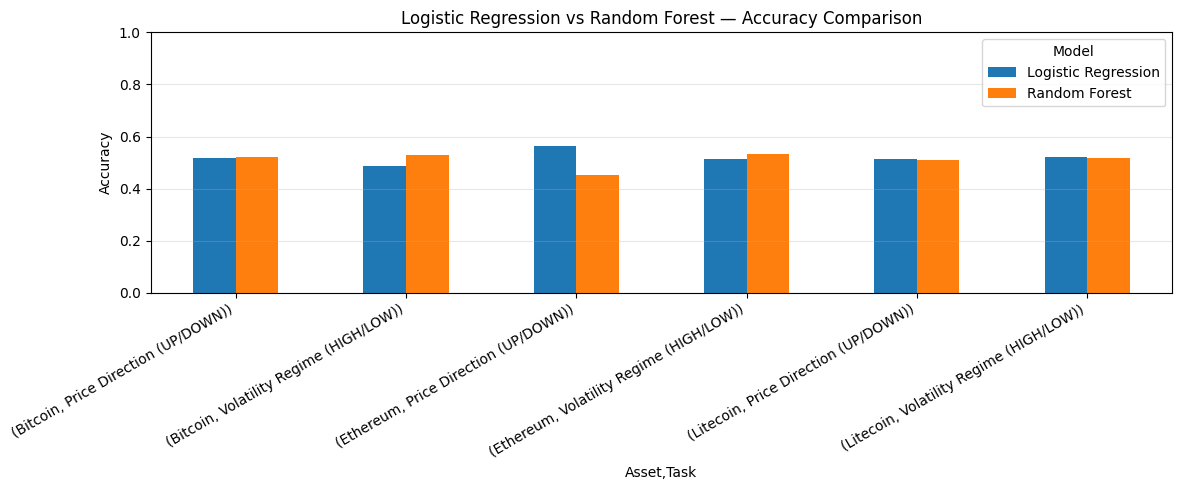

In [11]:
"""
Logistic Regression + Random Forest
for Bitcoin, Ethereum, Litecoin
Tasks:
  1) Price direction: UP(1) / DOWN(0)
  2) Volatility regime: HIGH(1) / LOW(0)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# =========================
# 1) LOAD + FEATURES
# =========================
def load_and_prepare(path, name):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    if "Volume" in df.columns:
        df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")
    else:
        df["Volume"] = np.nan

    df = df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)

    # Returns & volatility
    df["ret"] = np.log(df["Close"] / df["Close"].shift(1)) * 100
    df["vol_30"] = df["ret"].rolling(30).std()

    # SMA features (links to your SMA analysis)
    df["sma_30"] = df["Close"].rolling(30).mean()
    df["sma_90"] = df["Close"].rolling(90).mean()
    df["sma_spread"] = (df["sma_30"] - df["sma_90"]) / df["Close"] * 100

    # Lag features
    df["ret_1"] = df["ret"].shift(1)
    df["ret_2"] = df["ret"].shift(2)
    df["ret_3"] = df["ret"].shift(3)
    df["vol_lag"] = df["vol_30"].shift(1)
    df["vol_change"] = df["Volume"].pct_change()

    # Labels (next day)
    df["price_class"] = (df["ret"].shift(-1) > 0).astype(int)  # 1=UP, 0=DOWN

    next_abs = df["ret"].shift(-1).abs()
    thr = next_abs.rolling(30).median()
    df["vol_class"] = (next_abs > thr).astype(int)  # 1=HIGH, 0=LOW

    df = df.dropna().copy()
    df["Asset"] = name
    return df


FILES = {
    "Bitcoin": "BITCOIN24.csv",          # Colab: "/content/BITCOIN24.csv"
    "Ethereum": "ETHEREUM.csv",          # Colab: "/content/ETHEREUM.csv"
    "Litecoin": "LITECOIN24.csv",        # Colab: "/content/LITECOIN24.csv"
}

FEATURE_COLS = ["ret_1", "ret_2", "ret_3", "vol_lag", "sma_spread", "vol_change"]


# =========================
# 2) TRAIN + EVALUATE
# =========================
def evaluate_models(df, asset, target_col, task_name):
    X = df[FEATURE_COLS]
    y = df[target_col]

    # Time-based split (no shuffle)
    split = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, random_state=42)),
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ),
    }

    rows = []
    print("\n" + "=" * 70)
    print(f"{asset} | {task_name}")
    print("=" * 70)
    print(f"Train={len(X_train)} | Test={len(X_test)}")
    print("Test class balance:")
    print(y_test.value_counts(normalize=True).round(3))

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        print(f"\n--- {model_name} ---")
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1-score : {f1:.4f}")
        print(classification_report(y_test, pred, digits=3, zero_division=0))
        print("Confusion matrix:")
        print(confusion_matrix(y_test, pred))

        rows.append({
            "Asset": asset,
            "Task": task_name,
            "Model": model_name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1": round(f1, 4),
        })

    return rows


# =========================
# 3) RUN FOR ALL 3 COINS
# =========================
all_results = []

for asset, path in FILES.items():
    data = load_and_prepare(path, asset)

    all_results += evaluate_models(
        data, asset, "price_class", "Price Direction (UP/DOWN)"
    )
    all_results += evaluate_models(
        data, asset, "vol_class", "Volatility Regime (HIGH/LOW)"
    )

results_df = pd.DataFrame(all_results)
print("\n" + "#" * 70)
print("COMPARISON TABLE — ALL COINS / BOTH MODELS")
print("#" * 70)
print(results_df.to_string(index=False))

# Save table
results_df.to_csv("ml_comparison_btc_eth_ltc.csv", index=False)
print("\nSaved: ml_comparison_btc_eth_ltc.csv")


# =========================
# 4) ONE COMPARISON PLOT
# =========================
# Accuracy bars for each coin/model/task
pivot = results_df.pivot_table(
    index=["Asset", "Task"],
    columns="Model",
    values="Accuracy"
)

ax = pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Logistic Regression vs Random Forest — Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


Logistic Regression — Bitcoin
Train size: 1728 | Test size: 433
Accuracy : 0.5173
Precision: 0.5177
Recall   : 0.9777
F1-score : 0.6770

Classification report:
              precision    recall  f1-score   support

           0      0.500     0.024     0.046       209
           1      0.518     0.978     0.677       224

    accuracy                          0.517       433
   macro avg      0.509     0.501     0.361       433
weighted avg      0.509     0.517     0.372       433

Confusion matrix [ [TN FP], [FN TP] ]:
[[  5 204]
 [  5 219]]

Feature importance (coefficients):
   Feature  Coefficient
sma_spread     0.063207
     ret_2    -0.038671
     ret_1     0.029571
   vol_lag     0.019445
vol_change    -0.014896
     ret_3    -0.009544

Logistic Regression — Ethereum
Train size: 1841 | Test size: 461
Accuracy : 0.5640
Precision: 0.5686
Recall   : 0.6144
F1-score : 0.5906

Classification report:
              precision    recall  f1-score   support

           0      0.558     0

/tmp/ipykernel_474/41938120.py:45: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["vol_change"] = df["Volume"].pct_change()



Logistic Regression — Litecoin
Train size: 1840 | Test size: 461
Accuracy : 0.5141
Precision: 0.5691
Recall   : 0.2905
F1-score : 0.3846

Classification report:
              precision    recall  f1-score   support

           0      0.494     0.759     0.599       220
           1      0.569     0.290     0.385       241

    accuracy                          0.514       461
   macro avg      0.532     0.525     0.492       461
weighted avg      0.533     0.514     0.487       461

Confusion matrix [ [TN FP], [FN TP] ]:
[[167  53]
 [171  70]]

Feature importance (coefficients):
   Feature  Coefficient
   vol_lag     0.051218
     ret_2    -0.037572
vol_change    -0.024560
     ret_3     0.023967
sma_spread     0.021238
     ret_1    -0.000512

############################################################
LOGISTIC REGRESSION COMPARISON — BTC / ETH / LTC
############################################################
   Asset  Accuracy  Precision  Recall     F1
 Bitcoin    0.5173     0.517

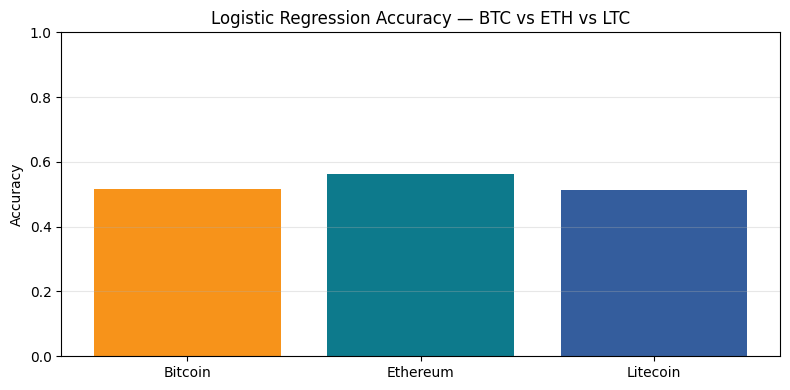

In [12]:
"""
Logistic Regression for Bitcoin, Ethereum, Litecoin
Predicts next-day price direction: UP (1) / DOWN (0)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

def load_and_prepare(path, name):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    if "Volume" in df.columns:
        df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")
    else:
        df["Volume"] = np.nan

    df = df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)

    # Features
    df["ret"] = np.log(df["Close"] / df["Close"].shift(1)) * 100
    df["vol_30"] = df["ret"].rolling(30).std()
    df["sma_30"] = df["Close"].rolling(30).mean()
    df["sma_90"] = df["Close"].rolling(90).mean()
    df["sma_spread"] = (df["sma_30"] - df["sma_90"]) / df["Close"] * 100

    df["ret_1"] = df["ret"].shift(1)
    df["ret_2"] = df["ret"].shift(2)
    df["ret_3"] = df["ret"].shift(3)
    df["vol_lag"] = df["vol_30"].shift(1)
    df["vol_change"] = df["Volume"].pct_change()

    # Target: next-day UP/DOWN
    df["price_class"] = (df["ret"].shift(-1) > 0).astype(int)

    df = df.dropna().copy()
    df["Asset"] = name
    return df


FILES = {
    "Bitcoin": "BITCOIN24.csv",      # Colab: "/content/BITCOIN24.csv"
    "Ethereum": "ETHEREUM.csv",      # Colab: "/content/ETHEREUM.csv"
    "Litecoin": "LITECOIN24.csv",    # Colab: "/content/LITECOIN24.csv"
}

FEATURE_COLS = ["ret_1", "ret_2", "ret_3", "vol_lag", "sma_spread", "vol_change"]

results = []

for asset, path in FILES.items():
    df = load_and_prepare(path, asset)

    X = df[FEATURE_COLS]
    y = df["price_class"]

    # Time-based split (no shuffle)
    split = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # Logistic Regression model
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    print("\n" + "=" * 60)
    print(f"Logistic Regression — {asset}")
    print("=" * 60)
    print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, pred, digits=3, zero_division=0))
    print("Confusion matrix [ [TN FP], [FN TP] ]:")
    print(confusion_matrix(y_test, pred))

    # Coefficients (easy explanation)
    coefs = model.named_steps["clf"].coef_[0]
    coef_table = pd.DataFrame({
        "Feature": FEATURE_COLS,
        "Coefficient": coefs
    }).sort_values("Coefficient", key=abs, ascending=False)
    print("\nFeature importance (coefficients):")
    print(coef_table.to_string(index=False))

    results.append({
        "Asset": asset,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    })

# Comparison table
results_df = pd.DataFrame(results)
print("\n" + "#" * 60)
print("LOGISTIC REGRESSION COMPARISON — BTC / ETH / LTC")
print("#" * 60)
print(results_df.to_string(index=False))

results_df.to_csv("logistic_regression_comparison.csv", index=False)
print("\nSaved: logistic_regression_comparison.csv")

# Accuracy bar chart
plt.figure(figsize=(8, 4))
plt.bar(results_df["Asset"], results_df["Accuracy"], color=["#F7931A", "#0D7A8C", "#345D9D"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Logistic Regression Accuracy — BTC vs ETH vs LTC")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


LSTM — Bitcoin


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Samples train/test: 1775 / 444
RMSE (% return): 2.3790
MAE  (% return): 1.6195
Direction Accuracy (UP/DOWN): 0.4820

Direction classification report:
              precision    recall  f1-score   support

           0      0.479     0.860     0.615       214
           1      0.500     0.130     0.207       230

    accuracy                          0.482       444
   macro avg      0.490     0.495     0.411       444
weighted avg      0.490     0.482     0.404       444



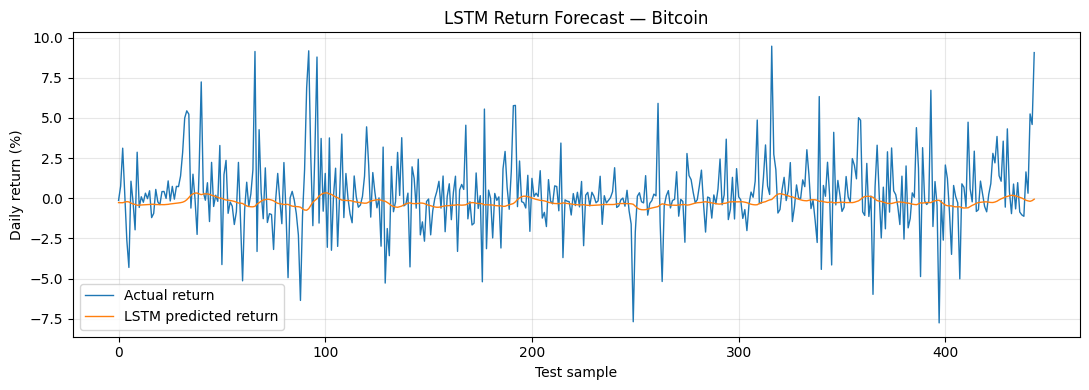

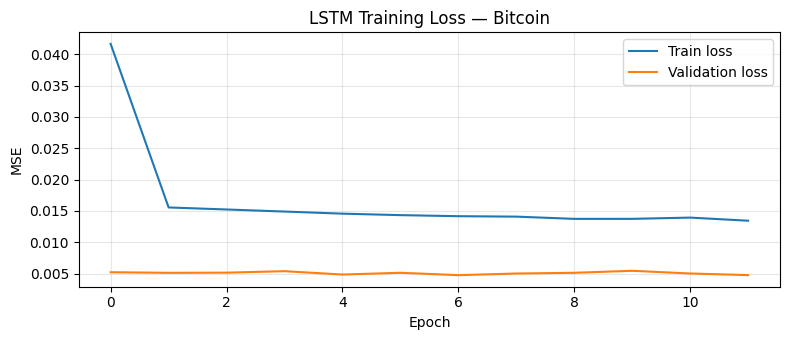


LSTM — Ethereum


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Samples train/test: 1888 / 472
RMSE (% return): 2.7198
MAE  (% return): 1.8636
Direction Accuracy (UP/DOWN): 0.4703

Direction classification report:
              precision    recall  f1-score   support

           0      0.385     0.153     0.219       229
           1      0.491     0.770     0.599       243

    accuracy                          0.470       472
   macro avg      0.438     0.461     0.409       472
weighted avg      0.439     0.470     0.415       472



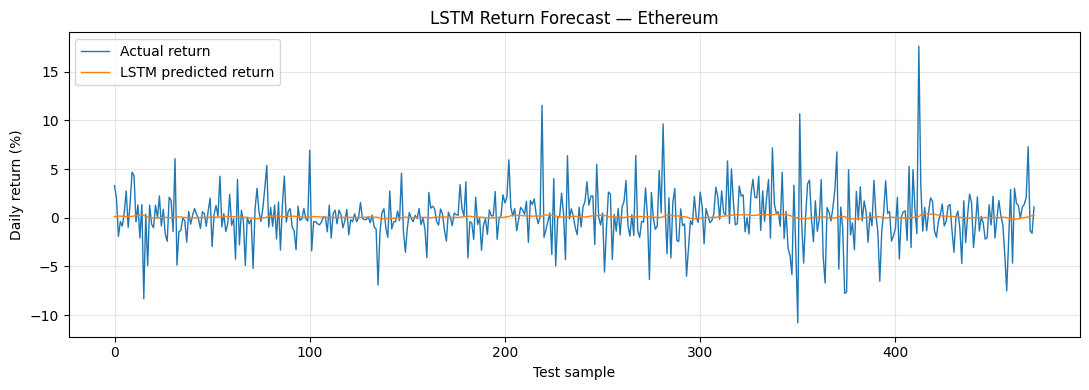

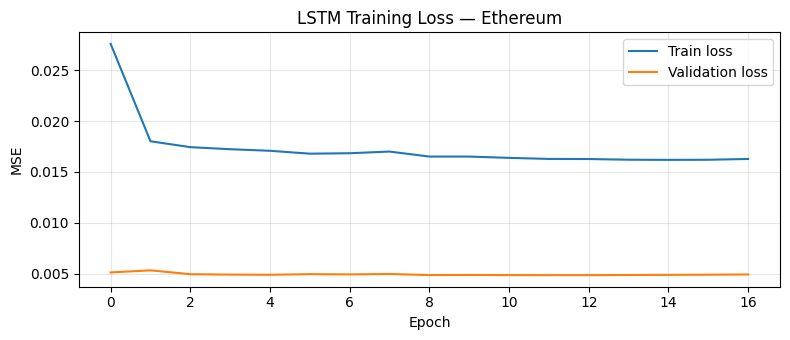


LSTM — Litecoin


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Samples train/test: 1898 / 475
RMSE (% return): 3.4790
MAE  (% return): 2.3132
Direction Accuracy (UP/DOWN): 0.4526

Direction classification report:
              precision    recall  f1-score   support

           0      0.420     0.383     0.401       227
           1      0.478     0.516     0.496       248

    accuracy                          0.453       475
   macro avg      0.449     0.450     0.449       475
weighted avg      0.450     0.453     0.451       475



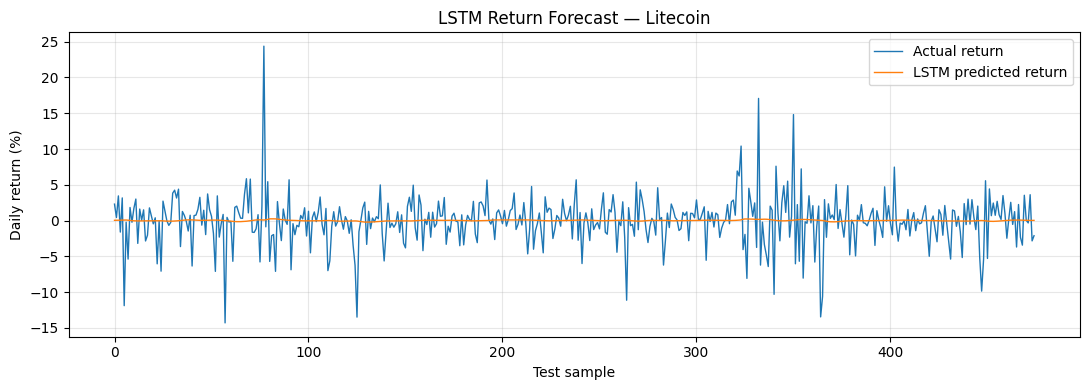

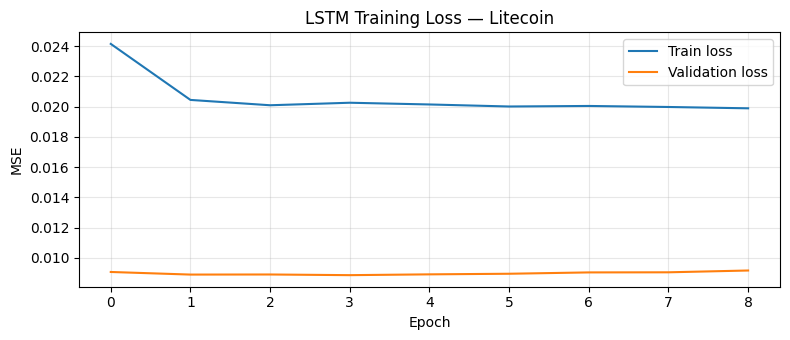


######################################################################
LSTM COMPARISON — BTC / ETH / LTC
######################################################################
   Asset   RMSE    MAE  Direction_Accuracy
 Bitcoin 2.3790 1.6195              0.4820
Ethereum 2.7198 1.8636              0.4703
Litecoin 3.4790 2.3132              0.4526

Saved: lstm_comparison_btc_eth_ltc.csv


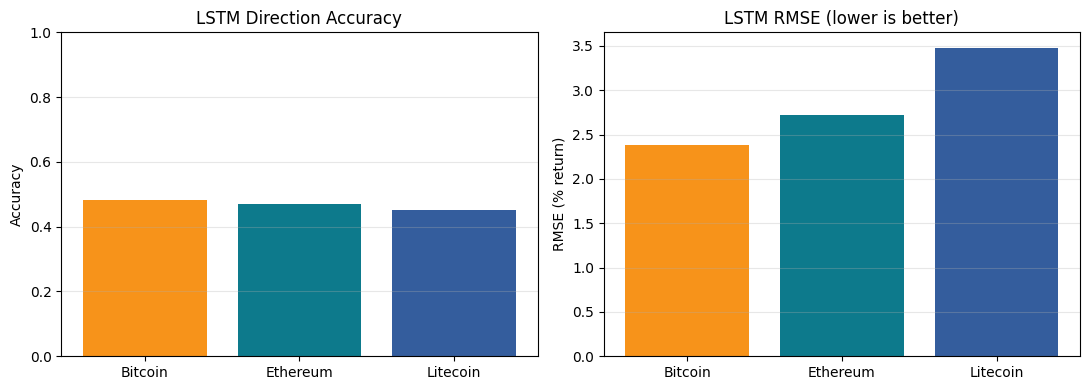

In [13]:
"""
LSTM for Bitcoin, Ethereum, Litecoin
Predicts next-day log return, then classifies UP/DOWN
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

# =========================
# SETTINGS
# =========================
LOOKBACK = 30          # use last 30 days as input sequence
EPOCHS = 30
BATCH_SIZE = 32
TEST_RATIO = 0.2

FILES = {
    "Bitcoin": "BITCOIN24.csv",      # Colab: "/content/BITCOIN24.csv"
    "Ethereum": "ETHEREUM.csv",      # Colab: "/content/ETHEREUM.csv"
    "Litecoin": "LITECOIN24.csv",    # Colab: "/content/LITECOIN24.csv"
}


# =========================
# LOAD + PREPARE
# =========================
def load_series(path):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)

    # daily log return (%)
    df["ret"] = np.log(df["Close"] / df["Close"].shift(1)) * 100
    df = df.dropna().reset_index(drop=True)
    return df


def make_sequences(values, lookback=30):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i, 0])
        y.append(values[i, 0])
    X = np.array(X)
    y = np.array(y)
    # LSTM needs 3D input: [samples, timesteps, features]
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y


def build_lstm(lookback):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)  # predict next-day return
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


# =========================
# TRAIN ONE COIN
# =========================
def run_lstm_for_coin(asset, path):
    print("\n" + "=" * 70)
    print(f"LSTM — {asset}")
    print("=" * 70)

    df = load_series(path)
    series = df[["ret"]].values.astype("float32")

    # Scale returns
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaled = scaler.fit_transform(series)

    X, y = make_sequences(scaled, LOOKBACK)

    # Time-based split
    split = int(len(X) * (1 - TEST_RATIO))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = build_lstm(LOOKBACK)
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=0
    )

    # Predictions
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_inv = scaler.inverse_transform(y_pred_scaled).ravel()

    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mae = mean_absolute_error(y_test_inv, y_pred_inv)

    # Direction accuracy (UP/DOWN)
    true_dir = (y_test_inv > 0).astype(int)
    pred_dir = (y_pred_inv > 0).astype(int)
    dir_acc = accuracy_score(true_dir, pred_dir)

    print(f"Samples train/test: {len(X_train)} / {len(X_test)}")
    print(f"RMSE (% return): {rmse:.4f}")
    print(f"MAE  (% return): {mae:.4f}")
    print(f"Direction Accuracy (UP/DOWN): {dir_acc:.4f}")
    print("\nDirection classification report:")
    print(classification_report(true_dir, pred_dir, digits=3, zero_division=0))

    # Plot actual vs predicted returns
    plt.figure(figsize=(11, 4))
    plt.plot(y_test_inv, label="Actual return", lw=1.0)
    plt.plot(y_pred_inv, label="LSTM predicted return", lw=1.0)
    plt.title(f"LSTM Return Forecast — {asset}")
    plt.ylabel("Daily return (%)")
    plt.xlabel("Test sample")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 3.5))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"LSTM Training Loss — {asset}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "Asset": asset,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "Direction_Accuracy": round(dir_acc, 4),
    }


# =========================
# RUN ALL 3 CSV FILES
# =========================
results = []
for asset, path in FILES.items():
    results.append(run_lstm_for_coin(asset, path))

results_df = pd.DataFrame(results)
print("\n" + "#" * 70)
print("LSTM COMPARISON — BTC / ETH / LTC")
print("#" * 70)
print(results_df.to_string(index=False))

results_df.to_csv("lstm_comparison_btc_eth_ltc.csv", index=False)
print("\nSaved: lstm_comparison_btc_eth_ltc.csv")

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(results_df["Asset"], results_df["Direction_Accuracy"],
            color=["#F7931A", "#0D7A8C", "#345D9D"])
axes[0].set_ylim(0, 1)
axes[0].set_title("LSTM Direction Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(results_df["Asset"], results_df["RMSE"],
            color=["#F7931A", "#0D7A8C", "#345D9D"])
axes[1].set_title("LSTM RMSE (lower is better)")
axes[1].set_ylabel("RMSE (% return)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Optional for LSTM tuning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

# =========================
# FILE PATHS
# =========================
FILES = {
    "Bitcoin": "BITCOIN24.csv",      # Colab: "/content/BITCOIN24.csv"
    "Ethereum": "ETHEREUM.csv",
    "Litecoin": "LITECOIN24.csv",
}

FEATURE_COLS = ["ret_1", "ret_2", "ret_3", "vol_lag", "sma_spread", "vol_change"]


# =========================
# DATA PREP
# =========================
def load_and_prepare(path, name):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    if "Volume" in df.columns:
        df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")
    else:
        df["Volume"] = np.nan

    df = df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)

    df["ret"] = np.log(df["Close"] / df["Close"].shift(1)) * 100
    df["vol_30"] = df["ret"].rolling(30).std()
    df["sma_30"] = df["Close"].rolling(30).mean()
    df["sma_90"] = df["Close"].rolling(90).mean()
    df["sma_spread"] = (df["sma_30"] - df["sma_90"]) / df["Close"] * 100

    df["ret_1"] = df["ret"].shift(1)
    df["ret_2"] = df["ret"].shift(2)
    df["ret_3"] = df["ret"].shift(3)
    df["vol_lag"] = df["vol_30"].shift(1)
    df["vol_change"] = df["Volume"].pct_change()

    # next-day UP/DOWN
    df["price_class"] = (df["ret"].shift(-1) > 0).astype(int)

    df = df.dropna().copy()
    df["Asset"] = name
    return df


def time_split(X, y, test_ratio=0.2):
    split = int(len(X) * (1 - test_ratio))
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]


# =========================
# 1) LOGISTIC REGRESSION TUNING
# =========================
def tune_logistic(X_train, y_train):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, random_state=42)),
    ])

    param_grid = {
        "clf__C": [0.01, 0.1, 1, 10, 100],          # regularization strength
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "liblinear"],
        "clf__class_weight": [None, "balanced"],
    }

    tscv = TimeSeriesSplit(n_splits=3)
    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=tscv,
        scoring="f1",
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train, y_train)
    return grid


# =========================
# 2) RANDOM FOREST TUNING
# =========================
def tune_random_forest(X_train, y_train):
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [4, 6, 8, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 3, 5],
        "max_features": ["sqrt", "log2"],
        "class_weight": [None, "balanced"],
    }

    tscv = TimeSeriesSplit(n_splits=3)

    # Randomized-style via GridSearch on a reduced grid is fine;
    # for speed you can use RandomizedSearchCV instead.
    from sklearn.model_selection import RandomizedSearchCV

    grid = RandomizedSearchCV(
        rf, param_grid, n_iter=20, cv=tscv, scoring="f1",
        n_jobs=-1, random_state=42
    )
    grid.fit(X_train, y_train)
    return grid


# =========================
# 3) LSTM TUNING (manual grid)
# =========================
def make_sequences(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i, 0])
        y.append(1 if values[i, 0] > 0 else 0)  # next-day direction from scaled? use raw below
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y


def build_lstm(lookback, units1, units2, dropout, lr):
    model = Sequential([
        LSTM(units1, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(dropout),
        LSTM(units2),
        Dropout(dropout),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),  # UP probability
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])
    return model


def tune_lstm(df):
    """
    Manual hyperparameter grid for LSTM.
    Target = next-day UP/DOWN from raw returns.
    """
    ret = df["ret"].values.astype("float32").reshape(-1, 1)

    # Direction labels from raw returns (shift already handled via sequence end)
    # We'll create sequences on raw returns, label = next return > 0
    lookbacks = [20, 30]
    units_list = [(32, 16), (64, 32)]
    dropouts = [0.1, 0.2]
    lrs = [0.001, 0.0005]
    batch_sizes = [32, 64]

    best = None
    results = []

    for lookback in lookbacks:
        # sequences on returns
        X_all, y_all = [], []
        values = ret.ravel()
        for i in range(lookback, len(values)):
            X_all.append(values[i - lookback:i])
            y_all.append(1 if values[i] > 0 else 0)
        X_all = np.array(X_all).reshape(-1, lookback, 1)
        y_all = np.array(y_all)

        split = int(len(X_all) * 0.8)
        X_train, X_test = X_all[:split], X_all[split:]
        y_train, y_test = y_all[:split], y_all[split:]

        # scale X only
        scaler = MinMaxScaler(feature_range=(-1, 1))
        X_train_2d = X_train.reshape(len(X_train), lookback)
        X_test_2d = X_test.reshape(len(X_test), lookback)
        X_train_s = scaler.fit_transform(X_train_2d).reshape(len(X_train), lookback, 1)
        X_test_s = scaler.transform(X_test_2d).reshape(len(X_test), lookback, 1)

        for (u1, u2) in units_list:
            for dropout in dropouts:
                for lr in lrs:
                    for bs in batch_sizes:
                        tf.keras.backend.clear_session()
                        model = build_lstm(lookback, u1, u2, dropout, lr)
                        es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
                        model.fit(
                            X_train_s, y_train,
                            validation_data=(X_test_s, y_test),
                            epochs=15,
                            batch_size=bs,
                            callbacks=[es],
                            verbose=0,
                        )
                        prob = model.predict(X_test_s, verbose=0).ravel()
                        pred = (prob >= 0.5).astype(int)
                        acc = accuracy_score(y_test, pred)
                        f1 = f1_score(y_test, pred, zero_division=0)

                        row = {
                            "lookback": lookback,
                            "units": f"{u1}-{u2}",
                            "dropout": dropout,
                            "lr": lr,
                            "batch_size": bs,
                            "accuracy": round(acc, 4),
                            "f1": round(f1, 4),
                        }
                        results.append(row)

                        if best is None or f1 > best["f1"]:
                            best = row.copy()

    return best, pd.DataFrame(results)


# =========================
# 4) ARIMA TUNING (AIC grid) — optional but useful
# =========================
def tune_arima_aic(df):
    from statsmodels.tsa.arima.model import ARIMA

    rets = df["ret"].dropna().reset_index(drop=True)
    best = None
    rows = []
    for p in range(0, 4):
        for q in range(0, 4):
            try:
                m = ARIMA(rets, order=(p, 0, q)).fit()
                row = {"p": p, "d": 0, "q": q, "AIC": round(m.aic, 2), "BIC": round(m.bic, 2)}
                rows.append(row)
                if best is None or m.aic < best["AIC"]:
                    best = row.copy()
            except Exception:
                pass
    return best, pd.DataFrame(rows).sort_values("AIC")


# =========================
# RUN EVERYTHING
# =========================
all_best = []

for asset, path in FILES.items():
    print("\n" + "#" * 72)
    print(f" HYPERPARAMETER TUNING — {asset}")
    print("#" * 72)

    df = load_and_prepare(path, asset)
    X = df[FEATURE_COLS]
    y = df["price_class"]
    X_train, X_test, y_train, y_test = time_split(X, y)

    # --- Logistic ---
    print("\n[1] Tuning Logistic Regression...")
    log_grid = tune_logistic(X_train, y_train)
    log_pred = log_grid.predict(X_test)
    print("Best params:", log_grid.best_params_)
    print("CV best F1 :", round(log_grid.best_score_, 4))
    print("Test Acc   :", round(accuracy_score(y_test, log_pred), 4))
    print("Test F1    :", round(f1_score(y_test, log_pred, zero_division=0), 4))

    all_best.append({
        "Asset": asset,
        "Model": "Logistic Regression",
        "Best_Params": str(log_grid.best_params_),
        "Test_Accuracy": round(accuracy_score(y_test, log_pred), 4),
        "Test_F1": round(f1_score(y_test, log_pred, zero_division=0), 4),
    })

    # --- Random Forest ---
    print("\n[2] Tuning Random Forest...")
    rf_grid = tune_random_forest(X_train, y_train)
    rf_pred = rf_grid.predict(X_test)
    print("Best params:", rf_grid.best_params_)
    print("CV best F1 :", round(rf_grid.best_score_, 4))
    print("Test Acc   :", round(accuracy_score(y_test, rf_pred), 4))
    print("Test F1    :", round(f1_score(y_test, rf_pred, zero_division=0), 4))

    all_best.append({
        "Asset": asset,
        "Model": "Random Forest",
        "Best_Params": str(rf_grid.best_params_),
        "Test_Accuracy": round(accuracy_score(y_test, rf_pred), 4),
        "Test_F1": round(f1_score(y_test, rf_pred, zero_division=0), 4),
    })

    # --- LSTM ---
    print("\n[3] Tuning LSTM (this can take several minutes)...")
    lstm_best, lstm_table = tune_lstm(df)
    print("Best LSTM config:")
    print(lstm_best)
    lstm_table.to_csv(f"lstm_tuning_{asset.lower()}.csv", index=False)

    all_best.append({
        "Asset": asset,
        "Model": "LSTM",
        "Best_Params": str(lstm_best),
        "Test_Accuracy": lstm_best["accuracy"],
        "Test_F1": lstm_best["f1"],
    })

    # --- ARIMA AIC ---
    print("\n[4] Tuning ARIMA by AIC...")
    arima_best, arima_table = tune_arima_aic(df)
    print("Best ARIMA:", arima_best)
    print(arima_table.head(5).to_string(index=False))
    arima_table.to_csv(f"arima_tuning_{asset.lower()}.csv", index=False)

    all_best.append({
        "Asset": asset,
        "Model": "ARIMA",
        "Best_Params": str(arima_best),
        "Test_Accuracy": np.nan,
        "Test_F1": np.nan,
    })

# Final summary
summary = pd.DataFrame(all_best)
print("\n" + "=" * 72)
print(" BEST HYPERPARAMETERS SUMMARY")
print("=" * 72)
print(summary.to_string(index=False))
summary.to_csv("hyperparameter_tuning_summary.csv", index=False)
print("\nSaved: hyperparameter_tuning_summary.csv")



########################################################################
 HYPERPARAMETER TUNING — Bitcoin
########################################################################

[1] Tuning Logistic Regression...
Best params: {'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
CV best F1 : 0.6592
Test Acc   : 0.5219
Test F1    : 0.684

[2] Tuning Random Forest...
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 4, 'class_weight': None}
CV best F1 : 0.6183
Test Acc   : 0.5035
Test F1    : 0.6098

[3] Tuning LSTM (this can take several minutes)...
Best LSTM config:
{'lookback': 30, 'units': '64-32', 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 64, 'accuracy': 0.5199, 'f1': 0.6841}

[4] Tuning ARIMA by AIC...
Best ARIMA: {'p': 3, 'd': 0, 'q': 3, 'AIC': np.float64(11614.32), 'BIC': np.float64(11659.75)}
 p  d  q      AIC      BIC
 3  0  3 11614.32 11659.75
 2  0  1 11615.29 11643.68